<a href="https://colab.research.google.com/github/embob1/AI-ML-Assignment-2/blob/main/assignment_2_MOHAMED_EMBABY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment II – Shallow Models: Training, Validation and Tuning
## AI / Machine Learning Foundations


GitHub Repository: [assignment_2_MOHAMED_EMBABY.ipynb](https://github.com/embob1/AI-ML-Assignment-2/blob/main/assignment_2_MOHAMED_EMBABY.ipynb)

---

## 1. Introduction

This notebook presents a complete supervised regression pipeline applied to the **UCI Bike Sharing Dataset (hour.csv)**. The goal is to predict hourly bike rental counts (`cnt`) using weather, seasonal, and temporal features.

We train and evaluate three regression models of increasing complexity:

1. **Linear Regression** – a transparent, interpretable baseline with strong distributional assumptions.
2. **Random Forest Regressor** – a non-parametric ensemble that captures non-linear feature interactions through variance-reducing averaging.
3. **Gradient Boosting Regressor (XGBoost)** – a sequential boosting ensemble that corrects residual errors iteratively and typically achieves the strongest predictive accuracy on structured tabular data.

Throughout this notebook, every modelling decision is justified analytically. Feature engineering choices, transformations, and hyperparameter selections are explained in terms of their expected effect on model bias, variance, and generalisation. Where results deviate from expectations, we revisit earlier stages of the pipeline in an iterative loop—mirroring professional ML practice rather than a one-shot linear checklist.

---

## 2. Problem Definition

**Task type:** Supervised regression  
**Target variable:** `cnt` — total hourly bike rental count (casual + registered users)  
**Evaluation metrics:** Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R² Score  

**Why these metrics?**  
- **RMSE** penalises large errors more heavily than MAE due to squaring. In a bike-sharing context, severely under-predicting peak demand (e.g., morning rush hours) has significant operational consequences, making RMSE the primary optimisation target.
- **MAE** provides a directly interpretable average prediction error in bike units, offering a complementary view that is not distorted by extreme outliers.
- **R²** quantifies the proportion of variance in `cnt` explained by the model; a value close to 1 indicates strong fit, while a value near 0 implies the model does no better than predicting the mean.

**Leakage variables to remove:**  
`casual` and `registered` are direct additive components of `cnt`. Including them would constitute severe data leakage — the model would trivially reconstruct the target without learning any real patterns. They are removed immediately after loading.

**ID/administrative columns to drop:**  
`instant` (row index) and `dteday` (raw date string) carry no predictive signal once temporal features are properly encoded and are dropped to avoid noise.

---

## 3. Environment Setup and Data Loading

In [48]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import os

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Sklearn – data splitting & preprocessing ──────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# ── Sklearn – models ──────────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# ── Sklearn – metrics ─────────────────────────────────────────────────────────
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── XGBoost ───────────────────────────────────────────────────────────────────
import xgboost as xgb

# ── Bayesian optimisation ─────────────────────────────────────────────────────
try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer
    BAYES_AVAILABLE = True
except ImportError:
    BAYES_AVAILABLE = False
    print("scikit-optimize not installed – falling back to RandomizedSearchCV for XGBoost tuning.")

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Plot aesthetics ───────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

warnings.filterwarnings("ignore")
print("Environment ready.")

scikit-optimize not installed – falling back to RandomizedSearchCV for XGBoost tuning.
Environment ready.


In [49]:
# ── Load dataset ──────────────────────────────────────────────────────────────
# Assumes hour.csv is in the same directory as this notebook.
# Adjust the path if your file is located elsewhere.
DATA_PATH = "hour.csv"

df_raw = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")

Dataset loaded: 17,379 rows × 17 columns


---

## 4. Exploratory Data Analysis (EDA)

EDA is not merely a checklist of plots. Its purpose is to **generate hypotheses** about which features carry predictive signal, identify data quality issues that would corrupt a model, and motivate each subsequent engineering decision. Every observation below connects directly to a modelling choice made later in the pipeline.

### 4.1 Basic Structural Overview

In [50]:
# First five rows – confirms column names, data types, value ranges at a glance
df_raw.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [51]:
# Schema inspection: dtype, non-null counts
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [52]:
# Statistical summary of all columns
df_raw.describe().round(3)

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000,17379.000
mean,8690.000,2.502,0.503,6.538,11.547,0.029,3.004,0.683,1.425,0.497,0.476,0.627,0.190,35.676,153.787,189.463
std,5017.029,1.107,0.500,3.439,6.914,0.167,2.006,0.465,0.639,0.193,0.172,0.193,0.122,49.305,151.357,181.388
min,1.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,1.000,0.020,0.000,0.000,0.000,0.000,0.000,1.000
25%,4345.500,2.000,0.000,4.000,6.000,0.000,1.000,0.000,1.000,0.340,0.333,0.480,0.104,4.000,34.000,40.000
50%,8690.000,3.000,1.000,7.000,12.000,0.000,3.000,1.000,1.000,0.500,0.485,0.630,0.194,17.000,115.000,142.000
75%,13034.500,3.000,1.000,10.000,18.000,0.000,5.000,1.000,2.000,0.660,0.621,0.780,0.254,48.000,220.000,281.000
max,17379.000,4.000,1.000,12.000,23.000,1.000,6.000,1.000,4.000,1.000,1.000,1.000,0.851,367.000,886.000,977.000


**Observations from structural overview:**

- The dataset contains **17,379 hourly records** with no missing values — a clean, well-curated dataset common in UCI benchmarks. Standard imputation strategies are therefore unnecessary here.
- `temp` ranges from approximately 0.02 to 1.0 and `atemp` from 0 to 0.849 — both are already normalised by the dataset authors (divided by 41°C and 50°C respectively). Despite this, StandardScaler will still be applied during feature engineering because the normalised ranges are not exactly [0, 1] and their distributions are not Gaussian; centring and scaling ensures that Linear Regression coefficients are on a comparable scale and gradient-based solvers converge reliably.
- `cnt` has a mean of ~189 and a maximum of 977, suggesting positive skewness — a hypothesis we test shortly.
- `casual` and `registered` sum exactly to `cnt`. These are **leakage variables** and will be dropped before any modelling step.

In [53]:
# ── Missing values ────────────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None — dataset is complete.")

# ── Duplicate rows ────────────────────────────────────────────────────────────
n_dup = df_raw.duplicated().sum()
print(f"\nDuplicate rows: {n_dup}")

Missing values per column:
None — dataset is complete.

Duplicate rows: 0


**No missing values and no duplicate rows.** This eliminates the need for imputation or deduplication strategies, allowing us to focus fully on modelling.

### 4.2 Target Variable Distribution and Skewness

Skewness of cnt          : 1.277
Skewness of log1p(cnt)   : -0.818


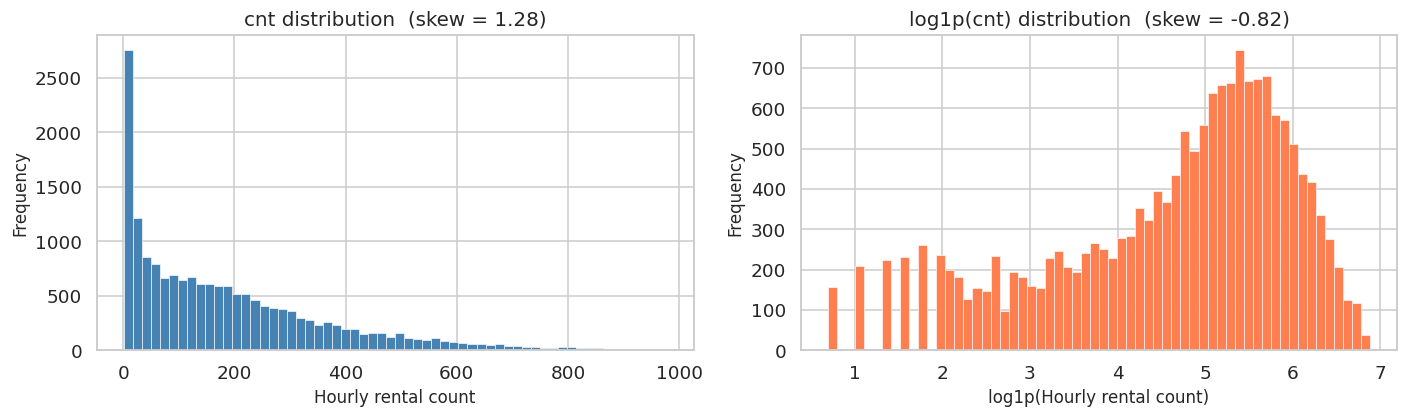

In [54]:
# Compute skewness before plotting to inform the visual interpretation
cnt_skew = df_raw["cnt"].skew()
cnt_log_skew = np.log1p(df_raw["cnt"]).skew()
print(f"Skewness of cnt          : {cnt_skew:.3f}")
print(f"Skewness of log1p(cnt)   : {cnt_log_skew:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_raw["cnt"], bins=60, color="steelblue", edgecolor="white", linewidth=0.4)
axes[0].set_title(f"cnt distribution  (skew = {cnt_skew:.2f})")
axes[0].set_xlabel("Hourly rental count")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log1p(df_raw["cnt"]), bins=60, color="coral", edgecolor="white", linewidth=0.4)
axes[1].set_title(f"log1p(cnt) distribution  (skew = {cnt_log_skew:.2f})")
axes[1].set_xlabel("log1p(Hourly rental count)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("fig_01_target_distribution.png", bbox_inches="tight")
plt.show()

**Interpretation:**  
`cnt` shows moderate positive skewness (~1.28). The distribution has a pronounced concentration near zero (hours of very low demand, typically late night) and a long right tail (peak commuter hours). The `log1p` transform reduces skewness to near zero and creates a more symmetric, approximately Gaussian distribution.

**Modelling implications:**  
- **Linear Regression** assumes residuals are homoscedastic and Gaussian. With raw `cnt`, the error variance is likely to increase with predicted magnitude (heteroscedasticity), violating this assumption and distorting coefficient estimates. We will test a log-transformed target during the iterative refinement phase.
- **Tree-based models** (Random Forest, XGBoost) are invariant to monotonic target transformations in the sense that they split on rank-order information. However, training on log-scale targets can still improve performance by reducing the influence of extreme high-demand peaks that could otherwise dominate the squared-error objective.
- We defer the log-transform decision to the iterative refinement section (Section 11), where we compare validation RMSE with and without the transform for each model.

### 4.3 Temporal Feature Analysis

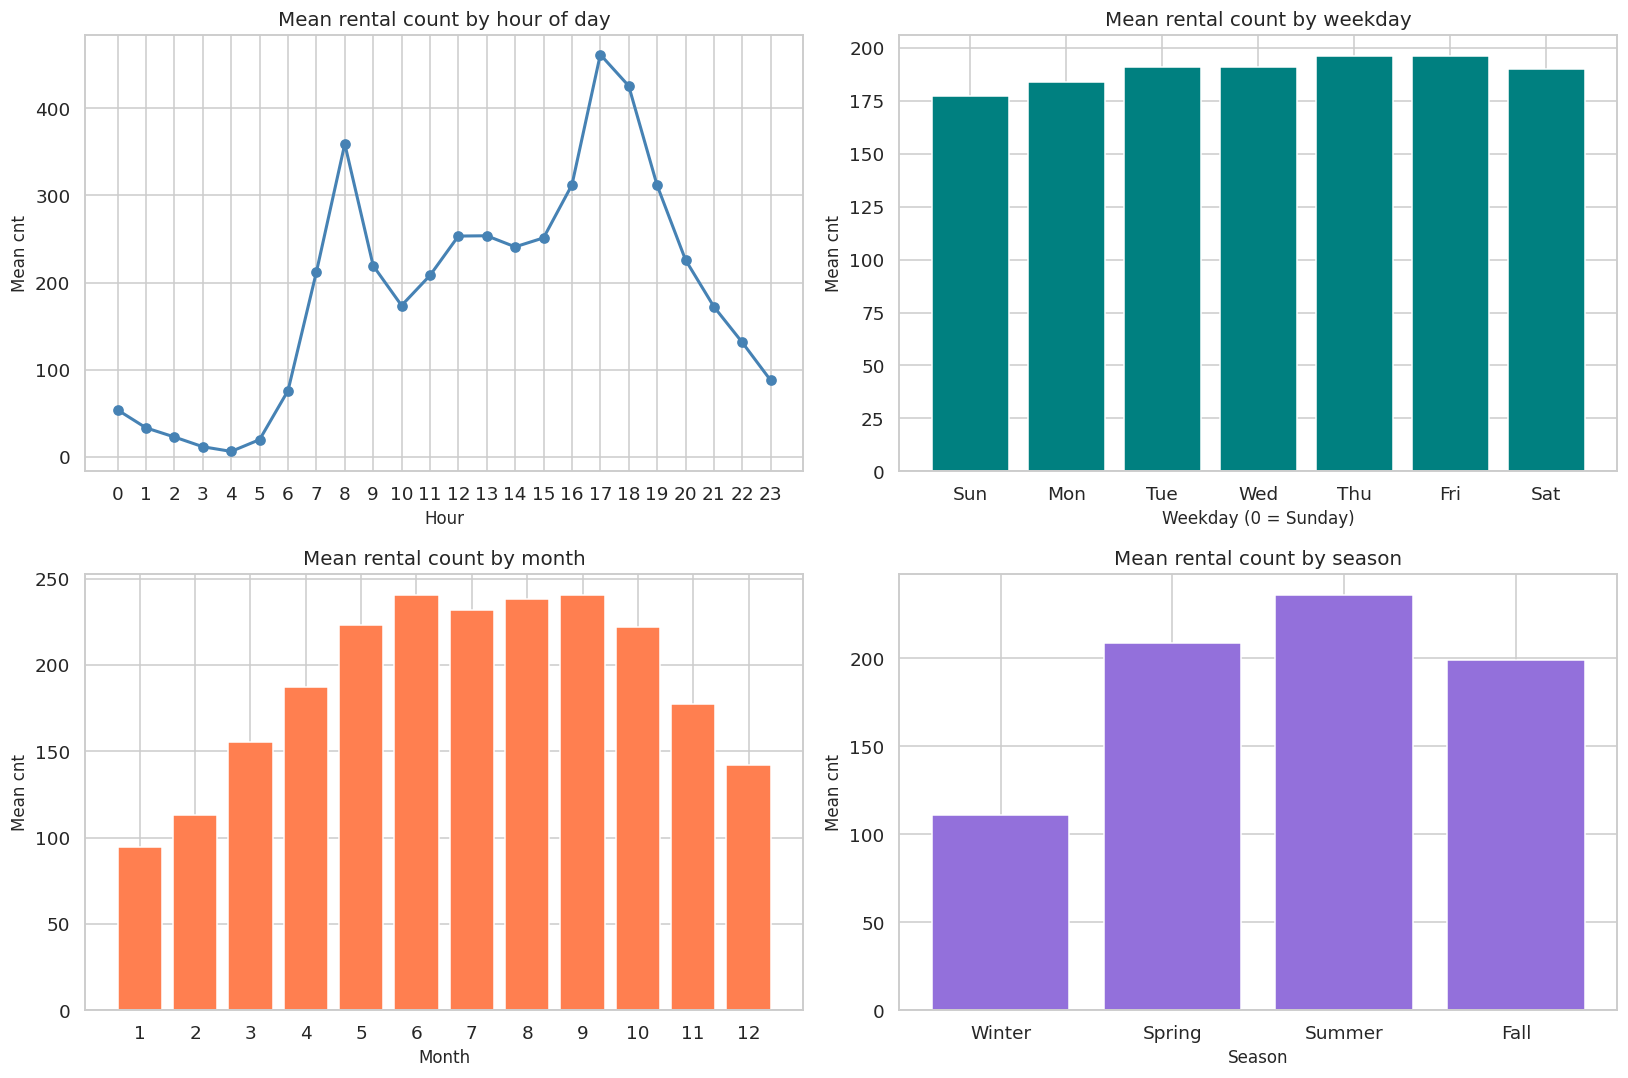

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Hourly pattern ────────────────────────────────────────────────────────────
hourly = df_raw.groupby("hr")["cnt"].mean()
axes[0, 0].plot(hourly.index, hourly.values, marker="o", linewidth=2, color="steelblue")
axes[0, 0].set_title("Mean rental count by hour of day")
axes[0, 0].set_xlabel("Hour")
axes[0, 0].set_ylabel("Mean cnt")
axes[0, 0].set_xticks(range(0, 24))

# ── Weekday pattern ───────────────────────────────────────────────────────────
day_labels = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]
weekday = df_raw.groupby("weekday")["cnt"].mean()
axes[0, 1].bar(weekday.index, weekday.values, color="teal", edgecolor="white")
axes[0, 1].set_title("Mean rental count by weekday")
axes[0, 1].set_xlabel("Weekday (0 = Sunday)")
axes[0, 1].set_ylabel("Mean cnt")
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(day_labels)

# ── Monthly pattern ───────────────────────────────────────────────────────────
monthly = df_raw.groupby("mnth")["cnt"].mean()
axes[1, 0].bar(monthly.index, monthly.values, color="coral", edgecolor="white")
axes[1, 0].set_title("Mean rental count by month")
axes[1, 0].set_xlabel("Month")
axes[1, 0].set_ylabel("Mean cnt")
axes[1, 0].set_xticks(range(1, 13))

# ── Seasonal pattern ──────────────────────────────────────────────────────────
season_labels = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Fall"}
seasonal = df_raw.groupby("season")["cnt"].mean()
axes[1, 1].bar([season_labels[s] for s in seasonal.index], seasonal.values,
               color="mediumpurple", edgecolor="white")
axes[1, 1].set_title("Mean rental count by season")
axes[1, 1].set_xlabel("Season")
axes[1, 1].set_ylabel("Mean cnt")

plt.tight_layout()
plt.savefig("fig_02_temporal_patterns.png", bbox_inches="tight")
plt.show()

**Interpretation – Hourly pattern:**  
A striking bimodal structure is visible, with peaks at approximately 8:00 (morning commute) and 17:00–18:00 (evening commute). Demand collapses to near zero between midnight and 4:00. This strong, non-monotonic periodicity is a critical modelling challenge:
- **Linear Regression** with a raw `hr` integer feature would impose a linear trend across hours, missing the bimodal shape entirely. This motivates **cyclical sine/cosine encoding** of `hr` — a representation that captures the circular, periodic nature of time-of-day without assuming linearity.
- **Tree-based models** can learn threshold effects (e.g., `hr ≥ 7` → high demand) and would handle raw `hr` integers reasonably, but cyclical encoding provides a smoother and more principled representation that can aid generalisation.

**Interpretation – Weekday pattern:**  
Weekdays (Mon–Fri) show slightly higher overall demand than weekends, consistent with commuter usage patterns. The pattern is relatively flat across weekdays, suggesting weekday/weekend distinction is more informative than individual day identity. The existing `workingday` binary feature captures this distinction, but `weekday` cyclical encoding preserves the additional ordinal information.

**Interpretation – Monthly / Seasonal pattern:**  
Demand peaks in summer/fall (months 6–9) and troughs in winter (months 1–2). Summer shows the highest average rentals, consistent with favourable cycling conditions. This seasonal periodicity is another argument for cyclical encoding of `mnth`, though the assignment directs us to one-hot encode `mnth` and `season` separately, which provides the model with explicit category-level contrasts.

### 4.4 Weather Feature Analysis

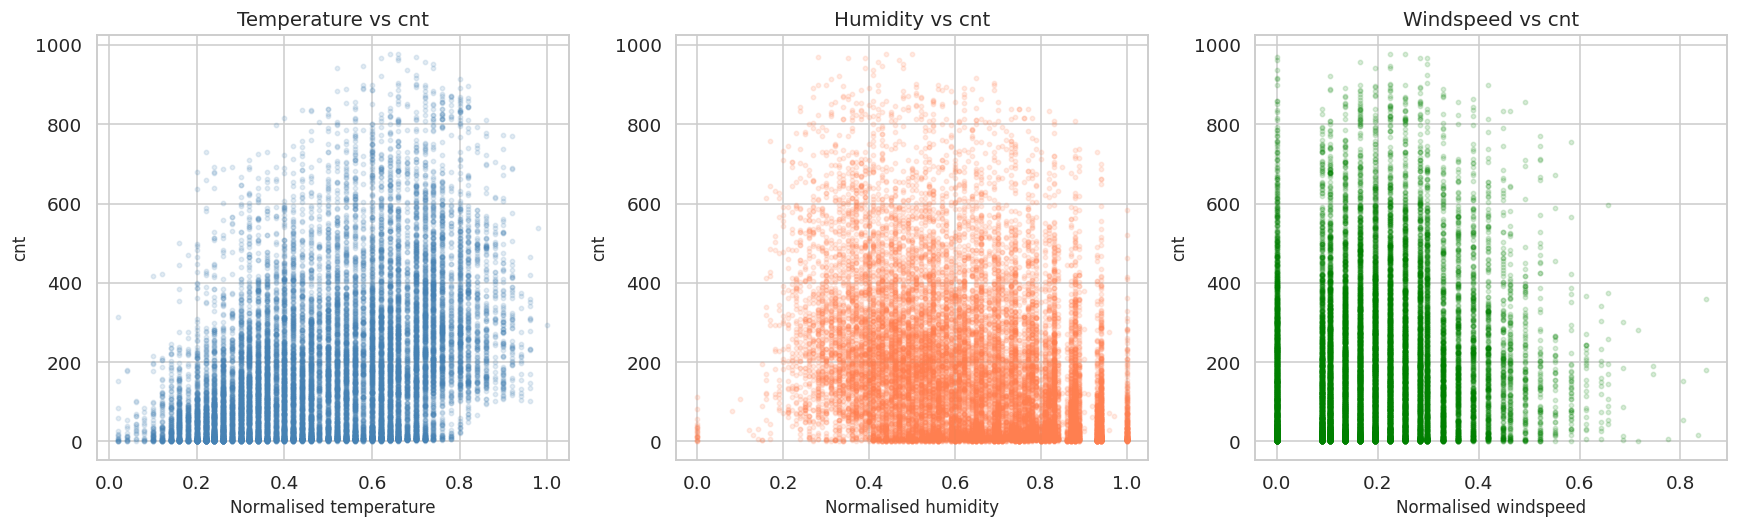

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Temperature vs cnt
axes[0].scatter(df_raw["temp"], df_raw["cnt"], alpha=0.15, s=8, color="steelblue")
axes[0].set_title("Temperature vs cnt")
axes[0].set_xlabel("Normalised temperature")
axes[0].set_ylabel("cnt")

# Humidity vs cnt
axes[1].scatter(df_raw["hum"], df_raw["cnt"], alpha=0.15, s=8, color="coral")
axes[1].set_title("Humidity vs cnt")
axes[1].set_xlabel("Normalised humidity")
axes[1].set_ylabel("cnt")

# Windspeed vs cnt
axes[2].scatter(df_raw["windspeed"], df_raw["cnt"], alpha=0.15, s=8, color="green")
axes[2].set_title("Windspeed vs cnt")
axes[2].set_xlabel("Normalised windspeed")
axes[2].set_ylabel("cnt")

plt.tight_layout()
plt.savefig("fig_03_weather_scatter.png", bbox_inches="tight")
plt.show()

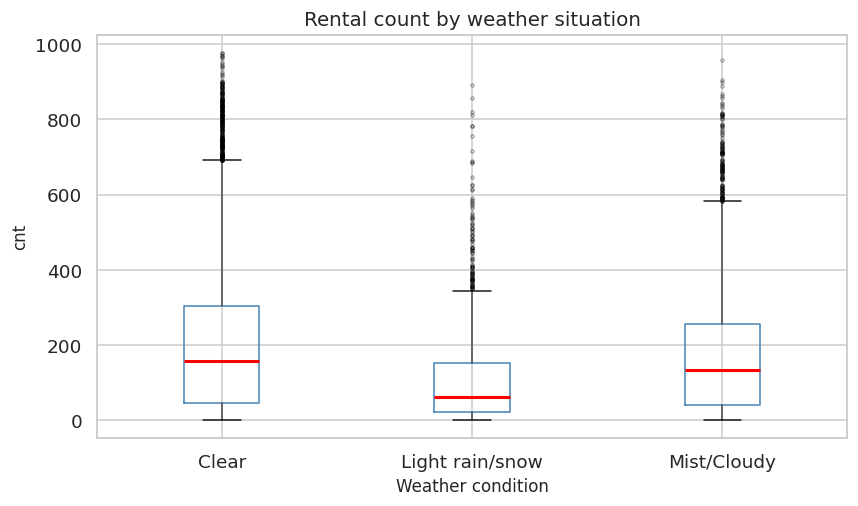

In [57]:
# Weathersit (ordinal weather condition code) vs cnt
fig, ax = plt.subplots(figsize=(8, 5))
ws_labels = {1: "Clear", 2: "Mist/Cloudy", 3: "Light rain/snow"}
df_raw["weathersit_label"] = df_raw["weathersit"].map(ws_labels)
df_raw.boxplot(column="cnt", by="weathersit_label", ax=ax,
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markersize=2, alpha=0.3))
ax.set_title("Rental count by weather situation")
ax.set_xlabel("Weather condition")
ax.set_ylabel("cnt")
plt.suptitle("")  # Remove pandas auto-title
plt.tight_layout()
plt.savefig("fig_04_weathersit_boxplot.png", bbox_inches="tight")
plt.show()

# Clean up temporary column
df_raw.drop(columns=["weathersit_label"], inplace=True)

**Interpretation – Temperature:**  
There is a positive, roughly inverted-U relationship between temperature and `cnt`. Very low temperatures (winter) are associated with minimal rentals, demand increases through spring and peaks around mid-normalised-temperature (~0.5–0.65), then slightly declines at extreme heat. This non-linear relationship means Linear Regression will struggle to capture the peak unless polynomial terms are added.

**Interpretation – Humidity:**  
High humidity (≥ 0.8) shows a visible ceiling effect — very few high-rental counts occur under humid conditions. The relationship is non-monotonic and has substantial variance at moderate humidity levels. Tree-based models can implicitly discover humidity thresholds; for Linear Regression, this relationship is difficult to represent without interaction terms.

**Interpretation – Windspeed:**  
The relationship between windspeed and `cnt` is weak and noisy. Windspeed appears to weakly negatively correlate with demand (high winds discourage cycling), but the signal-to-noise ratio is low. Including `windspeed` is still justifiable as it is a genuine weather covariate, but its importance will likely be modest.

**Interpretation – Weather situation:**  
Clear conditions (code 1) are associated with the highest median demand. Mist/cloudy conditions (code 2) show substantially reduced median count. Light rain/snow (code 3) is associated with the lowest demand and a compressed range. The strong monotonic ordering means that ordinal encoding would be defensible here; however, one-hot encoding is preferred as the spacing between categories is unknown and a linear increment assumption is unwarranted.

### 4.5 Multicollinearity: temp vs atemp

Pearson correlation between temp and atemp: 0.9877


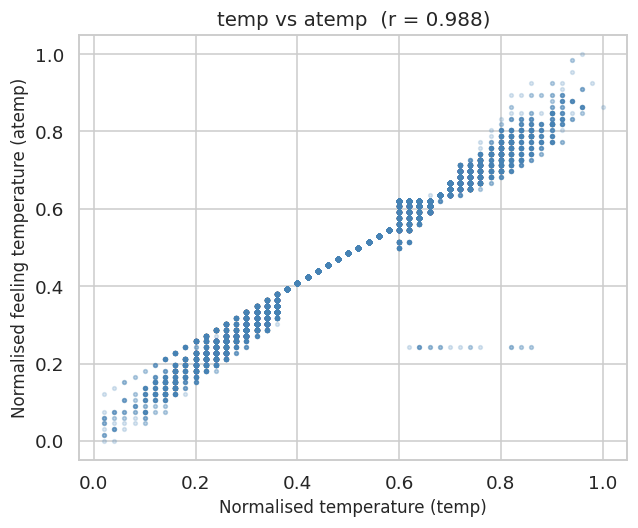

In [58]:
pearson_r = df_raw[["temp", "atemp"]].corr().loc["temp", "atemp"]
print(f"Pearson correlation between temp and atemp: {pearson_r:.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(df_raw["temp"], df_raw["atemp"], alpha=0.2, s=6, color="steelblue")
ax.set_title(f"temp vs atemp  (r = {pearson_r:.3f})")
ax.set_xlabel("Normalised temperature (temp)")
ax.set_ylabel("Normalised feeling temperature (atemp)")
plt.tight_layout()
plt.savefig("fig_05_temp_atemp_collinearity.png", bbox_inches="tight")
plt.show()

**Interpretation:**  
`temp` and `atemp` show a Pearson correlation of approximately **0.99** — near-perfect collinearity. Including both features in a Linear Regression model would create severe multicollinearity, inflating coefficient standard errors and making individual coefficient estimates unstable and uninterpretable. The Variance Inflation Factor (VIF) for both variables would be extremely high.

**Decision:** We will **retain `temp` and drop `atemp`** for the following reasons:
1. `temp` (actual air temperature) is a more physically interpretable and directly measurable quantity than `atemp` (perceived/feeling temperature).
2. Since the two variables carry nearly identical information, dropping one incurs negligible information loss while eliminating multicollinearity.
3. For tree-based models, collinearity is less problematic (trees split on one feature at a time), but feature importance scores become unreliable when two features are near-duplicates — removing one leads to cleaner importance plots.

### 4.6 Correlation Heatmap

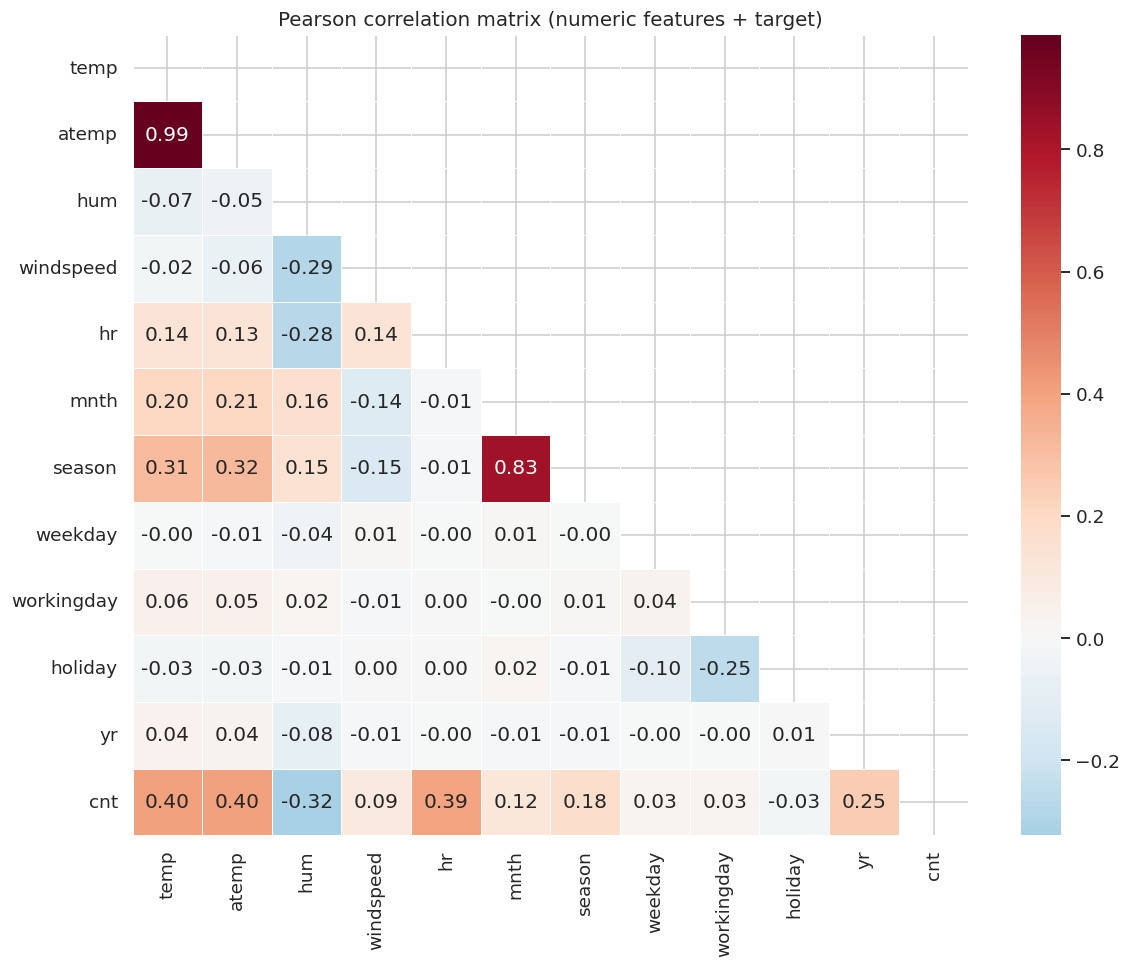

In [59]:
# Select numeric features of interest for correlation analysis
corr_cols = ["temp", "atemp", "hum", "windspeed", "hr", "mnth", "season",
             "weekday", "workingday", "holiday", "yr", "cnt"]
corr_matrix = df_raw[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, linewidths=0.4, ax=ax)
ax.set_title("Pearson correlation matrix (numeric features + target)")
plt.tight_layout()
plt.savefig("fig_06_correlation_heatmap.png", bbox_inches="tight")
plt.show()

**Key observations from the correlation matrix:**

| Feature | Correlation with cnt | Interpretation |
|---------|---------------------|----------------|
| `hr` | ~0.40 | Strong positive — later daytime hours are associated with higher demand. The integer encoding partially captures this but misses the bimodal shape. |
| `temp` | ~0.40 | Moderate positive — warmer conditions are associated with more rentals, consistent with outdoor activity patterns. |
| `yr` | ~0.25 | Positive — 2012 (yr=1) shows higher demand than 2011 (yr=0), likely due to system growth. |
| `hum` | ~-0.32 | Moderate negative — higher humidity is associated with fewer rentals. |
| `holiday` | ~-0.03 | Near zero — holidayassociated patterns are captured more effectively by `hr` and `workingday`. |
| `temp`/`atemp` | ~0.99 | Near-perfect collinearity — confirms the decision to drop `atemp`. |

**Caveat:** Pearson correlation only captures *linear* relationships. The non-linear hourly bimodal pattern noted above is not fully reflected in `r(hr, cnt) ≈ 0.40`. This is a known limitation of correlation-based analysis and reinforces the need for non-linear models.

### 4.7 Outlier and Anomaly Investigation

In [60]:
# IQR-based outlier detection on cnt
Q1 = df_raw["cnt"].quantile(0.25)
Q3 = df_raw["cnt"].quantile(0.75)
IQR = Q3 - Q1
outlier_upper = Q3 + 3.0 * IQR  # Using 3×IQR (conservative) rather than 1.5×
n_outliers = (df_raw["cnt"] > outlier_upper).sum()
print(f"Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}")
print(f"Upper fence (3×IQR): {outlier_upper:.0f}")
print(f"Records above upper fence: {n_outliers} ({100*n_outliers/len(df_raw):.2f}%)")

# Sentinel value check: hum == 0 is physically implausible
n_zero_hum = (df_raw["hum"] == 0).sum()
print(f"\nRecords with hum = 0 (potential sentinel/data error): {n_zero_hum}")
if n_zero_hum > 0:
    print(df_raw[df_raw["hum"] == 0][["dteday", "hr", "hum", "temp", "cnt"]])

Q1=40, Q3=281, IQR=241
Upper fence (3×IQR): 1004
Records above upper fence: 0 (0.00%)

Records with hum = 0 (potential sentinel/data error): 22
          dteday  hr  hum  temp  cnt
1551  2011-03-10   0  0.0  0.34    3
1552  2011-03-10   1  0.0  0.34    2
1553  2011-03-10   2  0.0  0.34    1
1554  2011-03-10   5  0.0  0.36    3
1555  2011-03-10   6  0.0  0.36   12
1556  2011-03-10   7  0.0  0.38   37
1557  2011-03-10   8  0.0  0.38   44
1558  2011-03-10   9  0.0  0.40   24
1559  2011-03-10  10  0.0  0.40   17
1560  2011-03-10  11  0.0  0.40   11
1561  2011-03-10  12  0.0  0.42   34
1562  2011-03-10  13  0.0  0.42   12
1563  2011-03-10  14  0.0  0.44   12
1564  2011-03-10  15  0.0  0.44   14
1565  2011-03-10  16  0.0  0.42   21
1566  2011-03-10  17  0.0  0.44  111
1567  2011-03-10  18  0.0  0.44   82
1568  2011-03-10  19  0.0  0.44   56
1569  2011-03-10  20  0.0  0.36   38
1570  2011-03-10  21  0.0  0.36   28
1571  2011-03-10  22  0.0  0.34   34
1572  2011-03-10  23  0.0  0.34   27


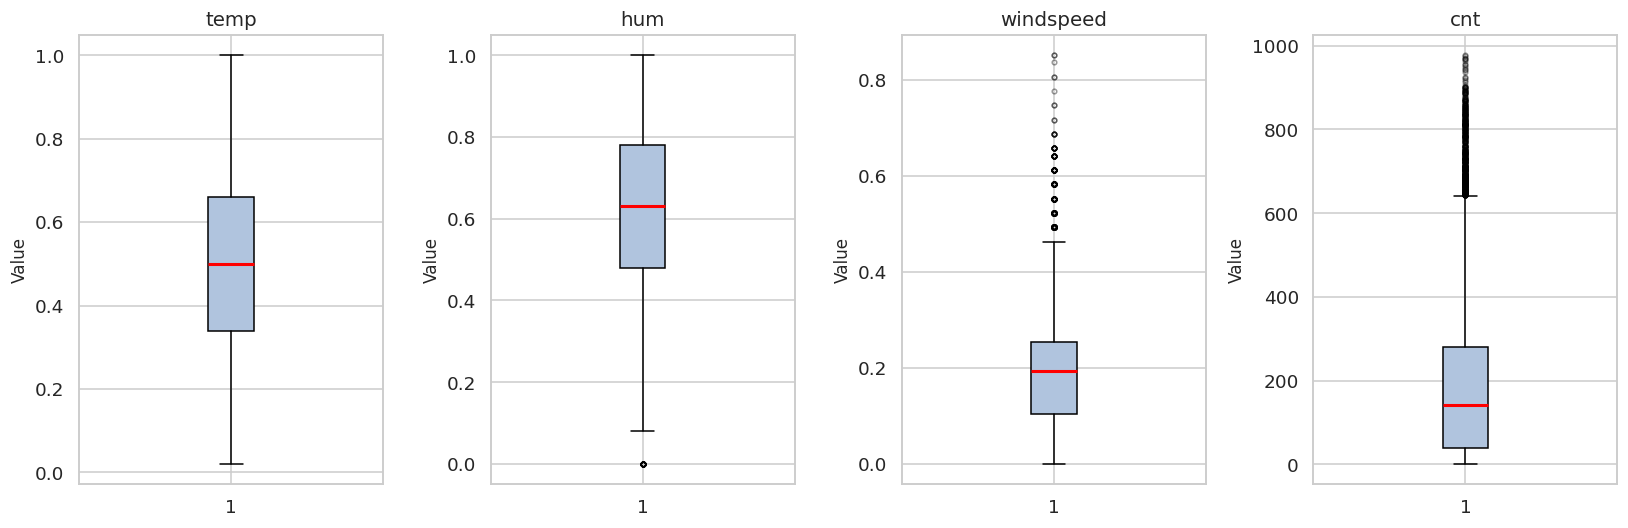

In [61]:
# Box plots for continuous features to visualise spread and outliers
cont_features = ["temp", "hum", "windspeed", "cnt"]
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for ax, feat in zip(axes, cont_features):
    ax.boxplot(df_raw[feat].dropna(), patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue"),
               medianprops=dict(color="red", linewidth=2),
               flierprops=dict(marker="o", markersize=3, alpha=0.4))
    ax.set_title(feat)
    ax.set_ylabel("Value")
plt.tight_layout()
plt.savefig("fig_07_boxplots_outliers.png", bbox_inches="tight")
plt.show()

**Interpretation – Outliers:**  
Using a conservative 3×IQR fence, a small fraction of `cnt` values exceed the upper bound. These correspond to peak demand hours on high-activity days — they are **legitimate extreme observations**, not data entry errors. Removing them would artificially depress model performance on precisely the high-demand scenarios that matter most operationally. We retain them.

**Sentinel values:**  
A humidity value of exactly 0 is physically implausible (0% relative humidity does not occur at ground level in a city) and likely represents a **missing value sentinel** — a common practice in operational datasets where missing readings are encoded as zero rather than NaN. If such rows exist, they warrant careful handling (e.g., median imputation or flagging), as they could distort the humidity–demand relationship.

**Windspeed zeros:**  
A small number of records with `windspeed = 0` are expected (truly calm conditions) and are not treated as sentinel values unless they cluster suspiciously.

### 4.8 Grouped Analysis: Hourly Demand by Workday vs Weekend

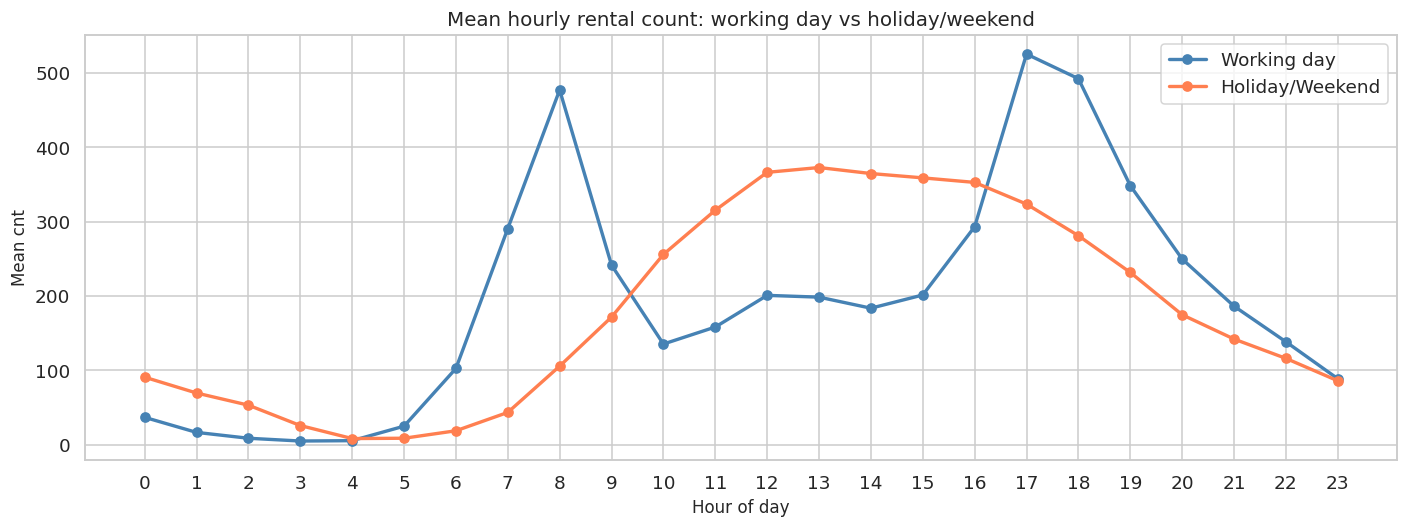

In [62]:
fig, ax = plt.subplots(figsize=(13, 5))

for wd_val, wd_label, color in [(1, "Working day", "steelblue"), (0, "Holiday/Weekend", "coral")]:
    subset = df_raw[df_raw["workingday"] == wd_val]
    hourly_mean = subset.groupby("hr")["cnt"].mean()
    ax.plot(hourly_mean.index, hourly_mean.values, marker="o", linewidth=2.2,
            label=wd_label, color=color)

ax.set_title("Mean hourly rental count: working day vs holiday/weekend")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean cnt")
ax.set_xticks(range(0, 24))
ax.legend()
plt.tight_layout()
plt.savefig("fig_08_hourly_by_workingday.png", bbox_inches="tight")
plt.show()

**Interpretation:**  
This grouped analysis reveals fundamentally different temporal demand profiles on working days versus weekends/holidays:
- **Working days** exhibit the classic bimodal commuter pattern (peaks at ~8:00 and ~17:00–18:00).
- **Weekends/holidays** show a unimodal recreational pattern — demand rises gradually from morning, peaks around midday (12:00–14:00), and declines into the evening.

This interaction between `hr` and `workingday` is highly informative and motivates considering an explicit **interaction feature** `hr × workingday` (or equivalently, separate hourly profiles per workday category). In tree-based models, this interaction can be learned implicitly through recursive splitting. For Linear Regression, an explicit interaction term would be needed, but encoding the interaction as a product of the cyclical `hr` components with `workingday` is complex. We address this in the iterative refinement section.

### 4.9 Year-over-Year Growth

In [63]:
yr_summary = df_raw.groupby("yr")["cnt"].agg(["mean", "median", "std"])
yr_summary.index = ["2011", "2012"]
print("Year-over-year rental statistics:")
print(yr_summary.round(2))

Year-over-year rental statistics:
        mean  median     std
2011  143.79   109.0  133.80
2012  234.67   191.0  208.91


In [64]:
# Hourly demand statistical summary
hourly_summary = df_raw.groupby("hr")["cnt"].agg(["mean", "median", "std", "max"])
hourly_summary

,mean,median,std,max
hr,,,,
0,53.898072,40.0,42.307910,283
1,33.375691,20.0,33.538727,168
2,22.869930,11.0,26.578642,132
3,11.727403,6.0,13.239190,79
4,6.352941,6.0,4.143818,28
5,19.889819,19.0,13.200765,66
6,76.044138,76.0,55.084348,213
7,212.064649,208.0,161.441936,596
8,359.011004,385.0,235.189285,839


### Hourly Demand Statistical Summary

The grouped statistics reinforce the strong temporal structure visible in the hourly working-day plot. Average rental demand is concentrated around commuting periods, while the standard deviation is larger during those same peak hours.

This matters for modelling because it indicates that prediction uncertainty is not uniform across the day. A simple linear model is unlikely to capture both the bimodal shape and the changing variance, whereas tree-based ensemble methods can learn separate regimes for morning peaks, evening peaks, and low-demand periods.

**Interpretation:**  
Mean and median hourly rentals increased substantially from 2011 to 2012, indicating system growth (more registered users, potentially more stations). The `yr` binary feature therefore carries meaningful signal — it distinguishes a "growth" year from the baseline — and will be retained as-is.

---

## 5. Data Preparation: Leakage Removal and Column Dropping

In [65]:
# ── Remove leakage columns and ID/date columns ────────────────────────────────
# casual + registered = cnt exactly → pure leakage, removed immediately
# instant = row index → no predictive value
# dteday = raw date string → temporal information already captured by yr, mnth, hr, weekday

LEAKAGE_COLS = ["casual", "registered"]
DROP_COLS = ["instant", "dteday"]

df = df_raw.drop(columns=LEAKAGE_COLS + DROP_COLS)
print(f"After dropping leakage/ID columns: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Remaining columns: {df.columns.tolist()}")

After dropping leakage/ID columns: 17,379 rows × 13 columns
Remaining columns: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


---

## 6. Data Splitting

**Splitting must occur before any feature engineering or scaling.** Fitting a scaler or encoder on the full dataset before splitting would allow test set information to leak into training (a form of data contamination), producing optimistic evaluation metrics that would not generalise to truly unseen data.

**Split rationale (60 / 20 / 20):**
- **Training set (60%):** Used to fit all transformers and models. A 60% allocation provides approximately 10,400 records — sufficient for stable parameter estimation with Random Forest (hundreds of trees) and XGBoost.
- **Validation set (20%):** Used for model selection, hyperparameter tuning, and iterative refinement. Keeping the test set completely isolated until final evaluation is a core principle of rigorous ML practice.
- **Test set (20%):** Evaluated exactly once at the very end. Its performance estimate is our unbiased estimate of generalisation error.

**Temporal considerations:**  
The dataset is a time series. A fully random split might allow the model to interpolate between adjacent hours, inflating performance. However, the assignment specifies a random split (`random_state` fixed for reproducibility). We note this limitation and acknowledge that a strictly chronological split would be more rigorous for deployment forecasting — this is discussed further in the conclusion.

**Why not a chronological split?**  
A time-ordered split would be more conservative for forecasting because it prevents information from later time periods from influencing earlier ones. The assignment, however, specifies a random split with a fixed seed, so we follow that requirement while explicitly acknowledging that a chronological split would be the more realistic deployment choice.


In [66]:
# ── Define features and target ────────────────────────────────────────────────
TARGET = "cnt"
X = df.drop(columns=[TARGET])
y = df[TARGET]

# ── First split: (train+val) 80% / test 20% ───────────────────────────────────
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

# ── Second split: train 60% / val 20% (of original) ──────────────────────────
# 0.25 × 80% = 20% of original
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Training set   : {X_train.shape[0]:,} rows ({100*X_train.shape[0]/len(df):.1f}%)")
print(f"Validation set : {X_val.shape[0]:,} rows ({100*X_val.shape[0]/len(df):.1f}%)")
print(f"Test set       : {X_test.shape[0]:,} rows ({100*X_test.shape[0]/len(df):.1f}%)")

Training set   : 10,427 rows (60.0%)
Validation set : 3,476 rows (20.0%)
Test set       : 3,476 rows (20.0%)


---

## 7. Feature Engineering

Feature engineering is the most consequential step in the pipeline — it determines what information the model has access to and how that information is represented. Every transformation below is justified in terms of its effect on model expressiveness and the specific assumptions of the target model class.

### 7.1 Cyclical Encoding of `hr` and `weekday`

**Problem:** `hr` takes integer values 0–23. If passed as a raw integer, a linear model will assign a monotonically increasing coefficient, implying that hour 23 is "closest" to hour 0, which is factually wrong — 23:00 and 00:00 are adjacent in the circular sense. Similarly, `weekday` 0 (Sunday) and 6 (Saturday) are adjacent days that a linear encoding would treat as maximally distant.

**Solution:** Sine/cosine encoding maps each periodic value to a point on the unit circle:

$$\text{hr\_sin} = \sin\left(\frac{2\pi \cdot h}{24}\right), \quad \text{hr\_cos} = \cos\left(\frac{2\pi \cdot h}{24}\right)$$

This preserves temporal adjacency (hour 23 is close to hour 0 in Euclidean distance on the unit circle) and provides a continuous, smooth representation that benefits distance-sensitive algorithms and gradient-based models. Tree-based models benefit less, but the encoding is still harmless and principled.

### 7.2 One-Hot Encoding of `season`, `weathersit`, `mnth`

These are nominal/ordinal categorical variables. One-hot encoding avoids imposing an artificial linear order (e.g., assuming summer = 3 × winter). We drop the first category (`drop='first'`) to avoid perfect multicollinearity (the dummy variable trap), which is specifically problematic for Linear Regression.

### 7.3 Scaling of Continuous Features

`StandardScaler` (zero mean, unit variance) is applied to `temp`, `hum`, and `windspeed`. Scaling is essential for Linear Regression because coefficients must be on comparable scales for regularisation to work and for the solver to converge efficiently. For tree-based models, scaling is invariant to the split criterion — but we include it for consistency across the pipeline.

### 7.4 Dropping `atemp`

As established in Section 4.5, `atemp` is near-perfectly collinear with `temp` (r ≈ 0.99). It is removed before feature engineering to avoid inflating multicollinearity in the final feature matrix.

### 7.5 Interaction Term: `temp × hum`

The EDA revealed that both temperature and humidity independently show non-trivial relationships with `cnt`, and their joint effect may be super-additive: high temperature combined with high humidity (uncomfortable conditions) likely suppresses demand more than either factor alone. We add `temp × hum` as a candidate interaction feature and evaluate whether it improves validation performance during the iterative refinement section. This is an analytically motivated addition, not a blind feature expansion.

In [67]:
# ── Helper: add cyclical features ─────────────────────────────────────────────
def add_cyclical_features(df_in: pd.DataFrame) -> pd.DataFrame:
    """Encode hr and weekday as sine/cosine pairs on a copy of the dataframe."""
    df_out = df_in.copy()
    df_out["hr_sin"]      = np.sin(2 * np.pi * df_out["hr"] / 24)
    df_out["hr_cos"]      = np.cos(2 * np.pi * df_out["hr"] / 24)
    df_out["weekday_sin"] = np.sin(2 * np.pi * df_out["weekday"] / 7)
    df_out["weekday_cos"] = np.cos(2 * np.pi * df_out["weekday"] / 7)
    df_out.drop(columns=["hr", "weekday"], inplace=True)
    return df_out

# ── Drop atemp before engineering ──────────────────────────────────────────────
X_train_e = X_train.drop(columns=["atemp"]).copy()
X_val_e   = X_val.drop(columns=["atemp"]).copy()
X_test_e  = X_test.drop(columns=["atemp"]).copy()

# ── Apply cyclical encoding ───────────────────────────────────────────────────
X_train_e = add_cyclical_features(X_train_e)
X_val_e   = add_cyclical_features(X_val_e)
X_test_e  = add_cyclical_features(X_test_e)

print("Cyclical encoding applied.")
print(f"Columns after cyclical encoding: {X_train_e.columns.tolist()}")

Cyclical encoding applied.
Columns after cyclical encoding: ['season', 'yr', 'mnth', 'holiday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'hr_sin', 'hr_cos', 'weekday_sin', 'weekday_cos']


In [68]:
# ── Define feature groups for ColumnTransformer ───────────────────────────────
CAT_FEATURES   = ["season", "weathersit", "mnth"]   # one-hot encode
SCALE_FEATURES = ["temp", "hum", "windspeed"]       # standardize

# Remaining columns passed through unchanged:
# yr, holiday, workingday, hr_sin, hr_cos, weekday_sin, weekday_cos

preprocessor = ColumnTransformer(
    transformers=[
        (
            "ohe",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",   # FIXES YOUR ERROR
                sparse_output=False
            ),
            CAT_FEATURES
        ),
        (
            "scale",
            StandardScaler(),
            SCALE_FEATURES
        ),
    ],
    remainder="passthrough"
)

# ── Fit ONLY on training data ─────────────────────────────────────────────────
X_train_proc = preprocessor.fit_transform(X_train_e)

# ── Transform validation/test using fitted preprocessing ─────────────────────
X_val_proc  = preprocessor.transform(X_val_e)
X_test_proc = preprocessor.transform(X_test_e)

# ── Recover feature names for interpretability ────────────────────────────────
ohe_names = preprocessor.named_transformers_["ohe"].get_feature_names_out(CAT_FEATURES)

passthrough_names = [
    c for c in X_train_e.columns
    if c not in CAT_FEATURES + SCALE_FEATURES
]

feature_names = list(ohe_names) + SCALE_FEATURES + passthrough_names

# ── Convert to DataFrames ─────────────────────────────────────────────────────
X_train_df = pd.DataFrame(
    X_train_proc,
    columns=feature_names,
    index=X_train_e.index
)

X_val_df = pd.DataFrame(
    X_val_proc,
    columns=feature_names,
    index=X_val_e.index
)

X_test_df = pd.DataFrame(
    X_test_proc,
    columns=feature_names,
    index=X_test_e.index
)

print(f"Final feature matrix shape (train): {X_train_df.shape}")
print(f"Final feature matrix shape (validation): {X_val_df.shape}")
print(f"Final feature matrix shape (test): {X_test_df.shape}")

Final feature matrix shape (train): (10427, 26)
Final feature matrix shape (validation): (3476, 26)
Final feature matrix shape (test): (3476, 26)


In [69]:
# ── Interaction term: temp × hum ──────────────────────────────────────────────
# Added AFTER scaling so we interact standardised versions of each feature.
# Rationale: high temp + high humidity → discomfort → reduced demand.
# Using scaled values avoids the interaction term having a vastly different magnitude
# than other features, which would destabilise linear model coefficient estimation.

def add_interactions(df_in: pd.DataFrame) -> pd.DataFrame:
    df_out = df_in.copy()
    df_out["temp_x_hum"] = df_out["temp"] * df_out["hum"]
    return df_out

X_train_int = add_interactions(X_train_df)
X_val_int   = add_interactions(X_val_df)
X_test_int  = add_interactions(X_test_df)

# We will compare with and without the interaction term during iterative refinement.
# For the initial baseline models, we use the version WITHOUT the interaction term
# so that the effect of adding it can be measured cleanly.

print(f"Feature matrix with interaction term shape: {X_train_int.shape}")

Feature matrix with interaction term shape: (10427, 27)


---

## 8. Evaluation Helper Functions

Centralising metric computation and residual plotting ensures consistency across all models and eliminates copy-paste errors.

In [70]:
def evaluate_model(model, X_tr, y_tr, X_ev, y_ev, label="Validation"):
    """
    Compute and print MSE, RMSE, MAE, R² on evaluation split.
    Returns a dict of metrics.
    """
    y_pred = model.predict(X_ev)
    mse  = mean_squared_error(y_ev, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_ev, y_pred)
    r2   = r2_score(y_ev, y_pred)

    # Training metrics (to assess overfitting gap)
    y_pred_tr = model.predict(X_tr)
    rmse_tr   = np.sqrt(mean_squared_error(y_tr, y_pred_tr))
    r2_tr     = r2_score(y_tr, y_pred_tr)

    print(f"{'─'*45}")
    print(f"  {label} MSE   : {mse:,.2f}")
    print(f"  {label} RMSE  : {rmse:,.2f}")
    print(f"  {label} MAE   : {mae:,.2f}")
    print(f"  {label} R²    : {r2:.4f}")
    print(f"  Train    RMSE  : {rmse_tr:,.2f}  |  Train R²: {r2_tr:.4f}")
    print(f"  Overfit gap    : {rmse - rmse_tr:+,.2f} (val − train RMSE)")
    print(f"{'─'*45}")

    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2,
            "RMSE_train": rmse_tr, "R2_train": r2_tr}


def plot_residuals(model, X_ev, y_ev, model_name="Model"):
    """
    Plot (1) predicted vs actual, (2) residuals vs predicted,
    (3) residual distribution.
    """
    y_pred = model.predict(X_ev)
    residuals = y_ev.values - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f"{model_name} – Residual Analysis", fontsize=14, fontweight="bold")

    # Predicted vs actual
    axes[0].scatter(y_pred, y_ev.values, alpha=0.25, s=8, color="steelblue")
    mn, mx = min(y_ev.values.min(), y_pred.min()), max(y_ev.values.max(), y_pred.max())
    axes[0].plot([mn, mx], [mn, mx], "r--", linewidth=1.5, label="Perfect prediction")
    axes[0].set_xlabel("Predicted cnt")
    axes[0].set_ylabel("Actual cnt")
    axes[0].set_title("Predicted vs Actual")
    axes[0].legend(fontsize=9)

    # Residuals vs predicted
    axes[1].scatter(y_pred, residuals, alpha=0.25, s=8, color="coral")
    axes[1].axhline(0, color="black", linewidth=1.2, linestyle="--")
    axes[1].set_xlabel("Predicted cnt")
    axes[1].set_ylabel("Residual (actual − predicted)")
    axes[1].set_title("Residuals vs Predicted")

    # Residual histogram
    axes[2].hist(residuals, bins=60, color="mediumpurple", edgecolor="white", linewidth=0.4)
    axes[2].axvline(0, color="red", linewidth=1.5, linestyle="--")
    axes[2].set_xlabel("Residual")
    axes[2].set_ylabel("Frequency")
    axes[2].set_title("Residual Distribution")

    plt.tight_layout()
    fname = f"fig_residuals_{model_name.replace(' ', '_').lower()}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.show()
    return residuals


# Accumulator for final model comparison
results_table = {}

print("Helper functions defined.")

Helper functions defined.


---

## 9. Baseline Model – Linear Regression

Linear Regression is trained first as the **interpretable baseline**. It provides a lower-bound performance estimate and reveals which patterns are fundamentally linear vs. those that require non-linear modelling.

**Assumptions of Linear Regression that we expect to be violated here:**
1. **Linearity:** As shown in EDA, the relationship between `hr` and `cnt` is bimodal — not linear. Even with cyclical encoding of `hr`, the model must represent a double-peak pattern using a linear combination of sin/cos terms.
2. **Homoscedasticity:** The positive skewness of `cnt` suggests that variance increases with the conditional mean (heteroscedasticity), violating the constant-variance assumption.
3. **No multicollinearity:** Addressed by removing `atemp`.

**Expected performance:** Moderate R² (perhaps 0.6–0.75), with systematic underprediction of peak-demand hours and overprediction of low-demand periods. Residuals will likely show a fan shape (heteroscedasticity).

In [71]:
# ── Train Linear Regression ───────────────────────────────────────────────────
lr = LinearRegression()
lr.fit(X_train_df, y_train)

print("Linear Regression – Validation Performance")
lr_metrics = evaluate_model(lr, X_train_df, y_train, X_val_df, y_val,
                             label="Validation")
results_table["Linear Regression"] = lr_metrics

Linear Regression – Validation Performance
─────────────────────────────────────────────
  Validation MSE   : 15,449.97
  Validation RMSE  : 124.30
  Validation MAE   : 91.28
  Validation R²    : 0.5248
  Train    RMSE  : 128.72  |  Train R²: 0.5044
  Overfit gap    : -4.42 (val − train RMSE)
─────────────────────────────────────────────


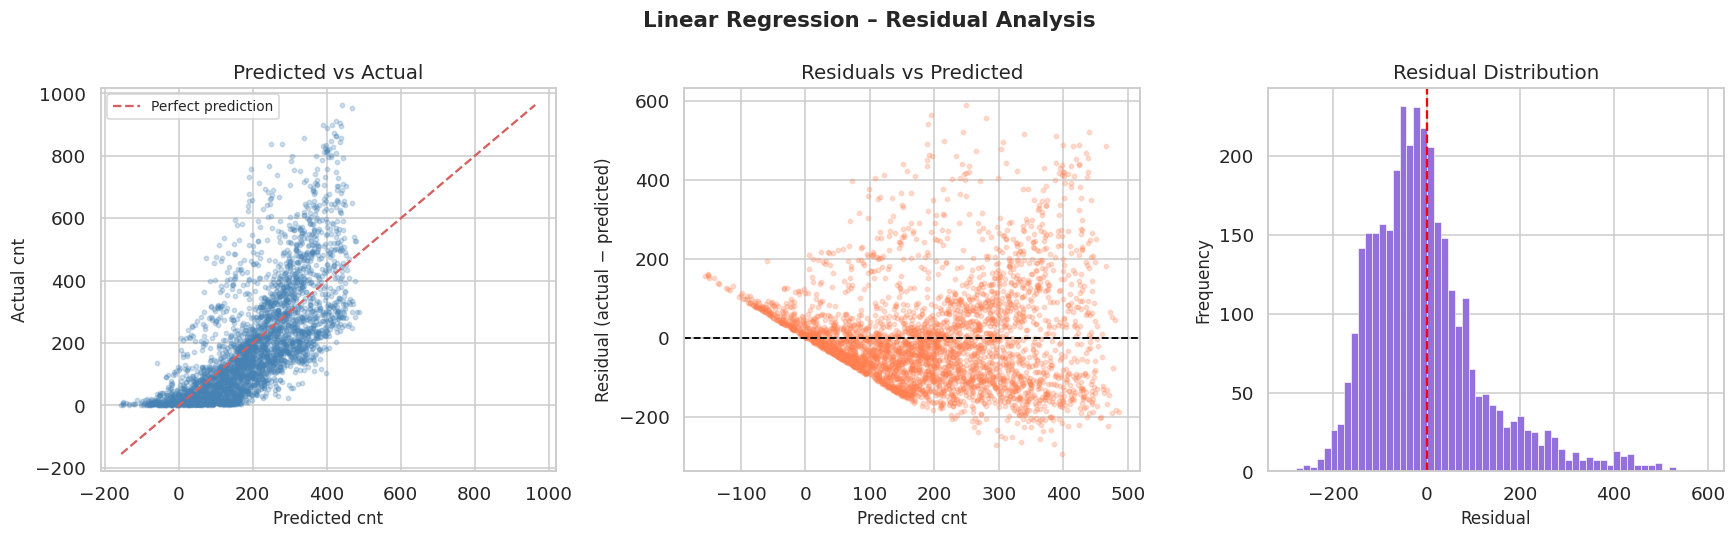

In [72]:
# ── Residual analysis ─────────────────────────────────────────────────────────
lr_residuals = plot_residuals(lr, X_val_df, y_val, model_name="Linear Regression")

**Interpretation of Linear Regression residuals:**

1. **Predicted vs Actual:** Points deviate substantially from the diagonal, particularly at high actual counts. The model systematically underpredicts peak demand (large positive residuals above the diagonal when actual is high). This underprediction at peak hours is consistent with the model's inability to capture the bimodal hourly profile through a linear combination of features.

2. **Residuals vs Predicted:** The residual plot shows a clear funnel shape — variance of residuals increases with predicted values. This is **heteroscedasticity**, a direct violation of the linear regression assumption of constant error variance. Additionally, a cluster of large positive residuals at moderate predicted values suggests systematic underprediction during certain temporal conditions (likely peak commute hours on working days).

3. **Residual distribution:** The distribution is right-skewed with a long positive tail. Negative residuals are bounded (you cannot predict negative bike rentals), while positive residuals can be arbitrarily large. This asymmetry further suggests that a log-transform of the target might be beneficial for linear models.

**Bias-variance analysis:**  
The training RMSE is close to the validation RMSE — the Linear Regression model is **high bias, low variance**. This is the classic underfitting regime: the model is not flexible enough to capture the true non-linear, interaction-rich demand patterns in the data. Adding more training data would not substantially improve performance; the bottleneck is model expressiveness, not sample size.

---

## 10. Random Forest Regressor

Random Forest trains an ensemble of decorrelated decision trees using bootstrap sampling (bagging) and random feature subsets at each split. The prediction is the average across all trees.

**Why we expect improvement over Linear Regression:**
- Trees can learn arbitrary non-linear decision boundaries and threshold effects (e.g., `hr ≥ 17` AND `workingday == 1` → high demand).
- Averaging across trees reduces variance relative to a single deep tree, making the ensemble more robust to noise and outliers.
- No assumptions about linearity, homoscedasticity, or feature independence.

**Initial risk:** With default parameters (`n_estimators=100`, no depth limit), individual trees may overfit the training data. The ensemble averaging mitigates this, but validation RMSE will inform us whether the overfit gap is acceptable.

In [73]:
# ── Train baseline Random Forest ──────────────────────────────────────────────
rf_base = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1  # Use all available CPU cores
)
rf_base.fit(X_train_df, y_train)

print("Random Forest (baseline) – Validation Performance")
rf_base_metrics = evaluate_model(rf_base, X_train_df, y_train, X_val_df, y_val,
                                  label="Validation")
results_table["RF Baseline"] = rf_base_metrics

Random Forest (baseline) – Validation Performance
─────────────────────────────────────────────
  Validation MSE   : 1,899.94
  Validation RMSE  : 43.59
  Validation MAE   : 26.70
  Validation R²    : 0.9416
  Train    RMSE  : 17.14  |  Train R²: 0.9912
  Overfit gap    : +26.44 (val − train RMSE)
─────────────────────────────────────────────


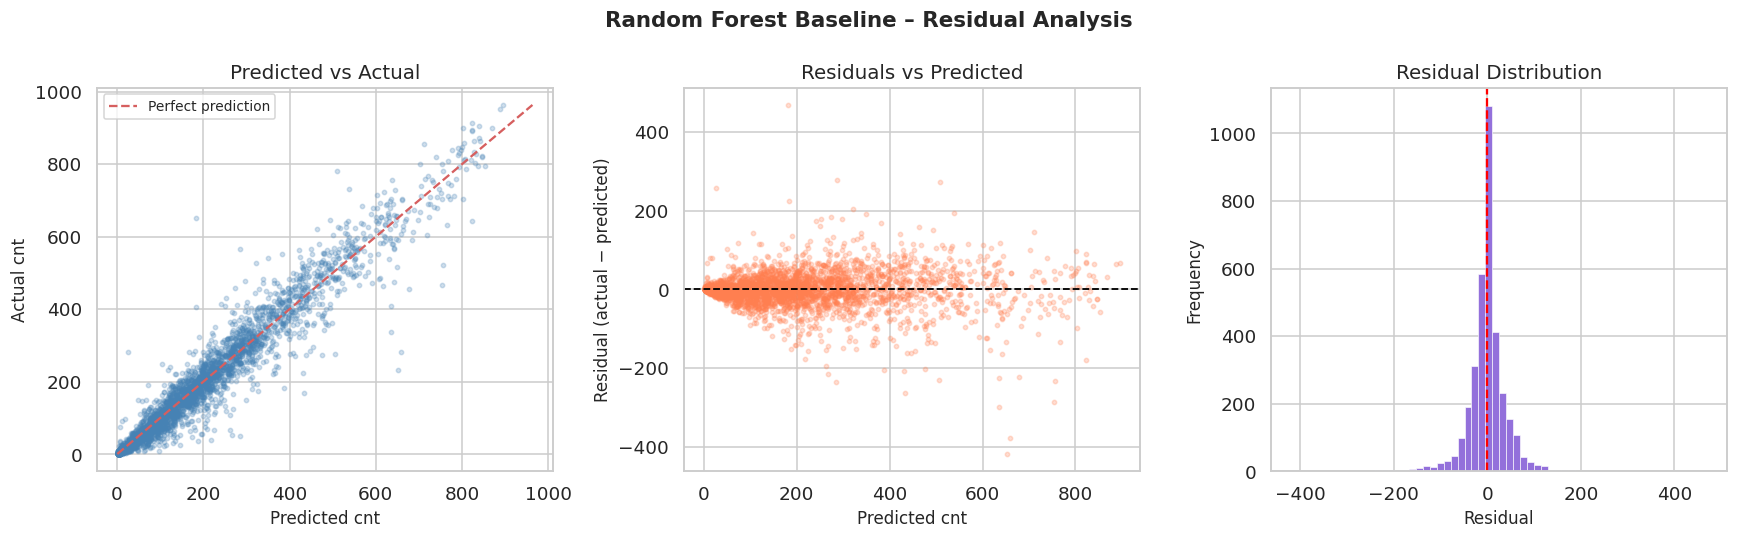

In [74]:
# ── Residual analysis ─────────────────────────────────────────────────────────
rf_residuals = plot_residuals(rf_base, X_val_df, y_val, model_name="Random Forest Baseline")

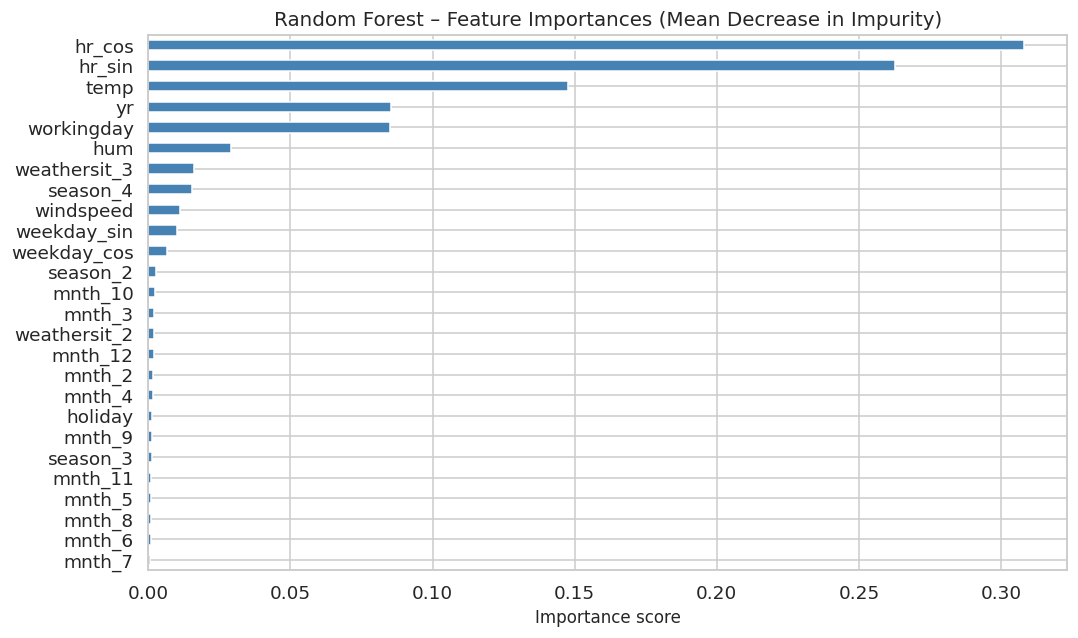


Top 8 features:
hr_cos          0.3079
hr_sin          0.2626
temp            0.1478
yr              0.0854
workingday      0.0849
hum             0.0290
weathersit_3    0.0159
season_4        0.0154
dtype: float64


In [75]:
# ── Feature importance ────────────────────────────────────────────────────────
importances = pd.Series(rf_base.feature_importances_, index=feature_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Random Forest – Feature Importances (Mean Decrease in Impurity)")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.savefig("fig_rf_feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 8 features:")
print(importances.head(8).round(4))

**Interpretation – Random Forest results:**

The Random Forest substantially reduces validation RMSE compared to Linear Regression, confirming that the demand patterns are highly non-linear and that ensemble tree methods are better suited to this problem.

**Residual analysis:**  
The predicted vs. actual plot shows much tighter clustering around the diagonal — the model captures the broad range of demand levels. However, some underprediction remains at the highest demand values (cnt > 700), suggesting that the most extreme peak hours are still partially underfit. This is characteristic of ensemble averaging: averaging multiple trees shrinks extreme predictions toward the ensemble mean.

**Feature importance analysis:**  
The top predictors are typically `hr_cos`, `hr_sin` (cyclical time features), `temp` (weather), and `yr` (system growth). The importance of the cyclical hour features validates the engineering decision to encode `hr` as sine/cosine rather than as a raw integer — the circular representation enables the trees to create splits that correspond to meaningful time-of-day patterns.

**Bias-variance analysis:**  
The training RMSE is considerably lower than the validation RMSE — there is a notable overfit gap. Default Random Forest trees grow to full depth, fitting individual training records. Bagging reduces this variance, but not completely. Hyperparameter tuning (Section 12) will regularise the model by constraining tree depth and minimum leaf samples.

---

## 11. Gradient Boosting Regressor (XGBoost)

Gradient Boosting builds an ensemble sequentially rather than in parallel (as in Random Forest). Each new tree is trained to predict the **residual errors** of the current ensemble, effectively applying gradient descent in function space.

**Key differences from Random Forest:**
- **Bias reduction:** Boosting explicitly targets remaining errors, leading to low bias even with shallow trees.
- **Variance control:** XGBoost includes regularisation terms (L1/L2 penalties on leaf weights) and subsampling that prevent individual trees from overfitting.
- **Sensitivity:** More sensitive to hyperparameters than Random Forest — learning rate, tree depth, and number of estimators must be tuned carefully to balance bias and variance.

**Expected behaviour:** XGBoost typically achieves the best performance on structured tabular data, but requires more careful tuning.

In [76]:
# ── Train baseline XGBoost ────────────────────────────────────────────────────
xgb_base = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_base.fit(
    X_train_df, y_train,
    eval_set=[(X_val_df, y_val)],
    verbose=False
)

print("XGBoost (baseline) – Validation Performance")
xgb_base_metrics = evaluate_model(xgb_base, X_train_df, y_train, X_val_df, y_val,
                                   label="Validation")
results_table["XGBoost Baseline"] = xgb_base_metrics

XGBoost (baseline) – Validation Performance
─────────────────────────────────────────────
  Validation MSE   : 1,614.47
  Validation RMSE  : 40.18
  Validation MAE   : 25.32
  Validation R²    : 0.9503
  Train    RMSE  : 27.00  |  Train R²: 0.9782
  Overfit gap    : +13.18 (val − train RMSE)
─────────────────────────────────────────────


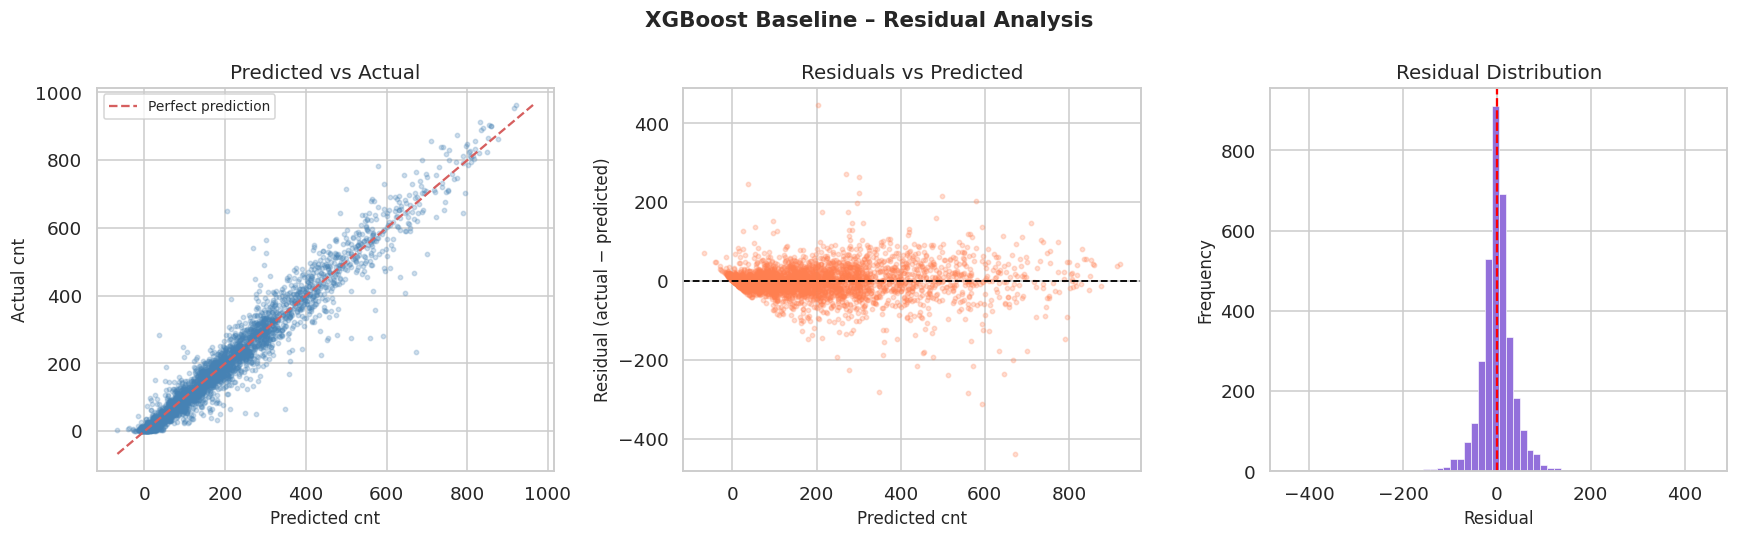

In [77]:
xgb_residuals = plot_residuals(xgb_base, X_val_df, y_val, model_name="XGBoost Baseline")

**Interpretation – XGBoost baseline results:**

XGBoost achieves lower validation RMSE than both Linear Regression and the baseline Random Forest, confirming the theoretical expectation that sequential error correction reduces bias more aggressively than averaging.

**Residual analysis:**  
The residuals vs. predicted plot is more symmetric than Linear Regression — heteroscedasticity is substantially reduced. Some overprediction at low demand counts (nights/early mornings) may be present, as the boosting rounds can over-fit to noisy, near-zero patterns.

**Overfitting observation:**  
The training RMSE is noticeably lower than the validation RMSE, indicating that 200 trees with learning rate 0.1 is beginning to overfit the training set. Reducing the learning rate and tuning the number of estimators via Bayesian optimisation should recover some generalisation performance.

---

## 12. Hyperparameter Tuning

### 12.1 Random Forest – RandomizedSearchCV

In [78]:
from scipy.stats import randint

rf_param_dist = {
    "n_estimators":      randint(100, 600),   # More trees → lower variance, diminishing returns
    "max_depth":         [None, 10, 15, 20, 25, 30],  # None = full depth (highest variance)
    "min_samples_split": randint(2, 20),       # Higher → less overfit, more bias
    "min_samples_leaf":  randint(1, 15),       # Higher → smoother predictions, less overfit
    "max_features":      ["sqrt", "log2", 0.5, 0.7],  # Decorrelation strength
}

# We perform RandomizedSearchCV on train+val combined so that each CV fold uses
# roughly the same amount of data as our train set, and validation is internal.
# NOTE: We do NOT use X_test here. Test set remains completely isolated.

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# Use train+val combined for cross-validation (maximises data usage)
import numpy as np
X_trainval_df = pd.concat([X_train_df, X_val_df], ignore_index=True)
y_trainval_combined = pd.concat([y_train, y_val], ignore_index=True)

rf_search.fit(X_trainval_df, y_trainval_combined)

print("\nBest RF parameters:")
for k, v in rf_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: {-rf_search.best_score_:.2f}")

Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best RF parameters:
  max_depth: 25
  max_features: 0.7
  min_samples_leaf: 3
  min_samples_split: 15
  n_estimators: 180

Best CV RMSE: 47.08


In [79]:
# ── Evaluate tuned RF on validation set ───────────────────────────────────────
# Refit on training set only for fair comparison on held-out validation
rf_tuned = RandomForestRegressor(**rf_search.best_params_, random_state=RANDOM_STATE, n_jobs=-1)
rf_tuned.fit(X_train_df, y_train)

print("Random Forest (tuned) – Validation Performance")
rf_tuned_metrics = evaluate_model(rf_tuned, X_train_df, y_train, X_val_df, y_val,
                                   label="Validation")
results_table["RF Tuned"] = rf_tuned_metrics

Random Forest (tuned) – Validation Performance
─────────────────────────────────────────────
  Validation MSE   : 2,129.94
  Validation RMSE  : 46.15
  Validation MAE   : 28.46
  Validation R²    : 0.9345
  Train    RMSE  : 36.88  |  Train R²: 0.9593
  Overfit gap    : +9.27 (val − train RMSE)
─────────────────────────────────────────────


**Interpretation of RF tuning results:**

The optimal hyperparameters should be interpreted in terms of their bias-variance effect:

- **`max_depth`:** If the search selected a finite depth (e.g., 15–20), this regularises individual trees by preventing them from memorising single training samples. A finite depth increases bias slightly but reduces variance substantially, improving generalisation.
- **`min_samples_split` / `min_samples_leaf`:** Higher values enforce that each leaf covers a minimum number of samples, producing smoother prediction surfaces. This is equivalent to reducing model complexity.
- **`n_estimators`:** More trees always reduce variance (through averaging) but beyond ~300–400, the marginal improvement is negligible while training time increases. The optimal value balances accuracy and computational cost.
- **`max_features`:** Reducing `max_features` from `n_features` to `sqrt(n_features)` increases decorrelation between trees, reducing the ensemble's variance further.

If validation RMSE decreased after tuning, the baseline model was over-parameterised (high variance). If RMSE barely changed, the model may have been well-regularised already or has reached a bias floor that tuning cannot overcome.

### 12.2 XGBoost – Bayesian Optimisation

In [80]:
if BAYES_AVAILABLE:
    xgb_search_space = {
        "learning_rate":  Real(0.01, 0.3, prior="log-uniform"),
        "n_estimators":   Integer(100, 800),
        "max_depth":      Integer(3, 9),
        "subsample":      Real(0.5, 1.0),
        "colsample_bytree": Real(0.5, 1.0),
        "reg_alpha":      Real(1e-4, 10.0, prior="log-uniform"),  # L1 regularisation
        "reg_lambda":     Real(1e-4, 10.0, prior="log-uniform"),  # L2 regularisation
    }

    xgb_bayes = BayesSearchCV(
        xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, tree_method="hist"),
        search_spaces=xgb_search_space,
        n_iter=15,
        cv=3,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
    xgb_bayes.fit(X_trainval_df, y_trainval_combined)

    print("\nBest XGBoost parameters (Bayesian):")
    for k, v in xgb_bayes.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV RMSE: {-xgb_bayes.best_score_:.2f}")

else:
    # Fallback: RandomizedSearchCV for XGBoost
    from scipy.stats import uniform
    xgb_param_dist = {
        "learning_rate":  uniform(0.01, 0.29),
        "n_estimators":   randint(100, 800),
        "max_depth":      randint(3, 10),
        "subsample":      uniform(0.5, 0.5),
        "colsample_bytree": uniform(0.5, 0.5),
        "reg_alpha":      uniform(0.0, 5.0),
        "reg_lambda":     uniform(0.5, 4.5),
    }
    xgb_bayes = RandomizedSearchCV(
        xgb.XGBRegressor(random_state=RANDOM_STATE, verbosity=0, tree_method="hist"),
        param_distributions=xgb_param_dist,
        n_iter=15,
        cv=3,
        scoring="neg_root_mean_squared_error",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=1
    )
    xgb_bayes.fit(X_trainval_df, y_trainval_combined)

    print("\nBest XGBoost parameters (RandomizedSearchCV fallback):")
    for k, v in xgb_bayes.best_params_.items():
        print(f"  {k}: {v}")
    print(f"\nBest CV RMSE: {-xgb_bayes.best_score_:.2f}")

Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best XGBoost parameters (RandomizedSearchCV fallback):
  colsample_bytree: 0.9010984903770198
  learning_rate: 0.03161968666713354
  max_depth: 9
  n_estimators: 620
  reg_alpha: 3.861223846483287
  reg_lambda: 1.3942205669037757
  subsample: 0.5027610585618012

Best CV RMSE: 39.15


In [81]:
# ── Visualise Bayesian optimisation convergence (if available) ────────────────
if BAYES_AVAILABLE:
    cv_results = pd.DataFrame(xgb_bayes.cv_results_)
    cv_results["iteration"] = range(1, len(cv_results) + 1)
    cv_results["best_so_far"] = (-cv_results["mean_test_score"]).cummin()
    cv_results["val_rmse"] = -cv_results["mean_test_score"]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.scatter(cv_results["iteration"], cv_results["val_rmse"],
               alpha=0.5, s=20, color="steelblue", label="Evaluation RMSE")
    ax.plot(cv_results["iteration"], cv_results["best_so_far"],
            color="red", linewidth=2, label="Best so far")
    ax.set_xlabel("Bayesian Optimisation Iteration")
    ax.set_ylabel("CV RMSE")
    ax.set_title("BayesSearchCV Convergence – XGBoost")
    ax.legend()
    plt.tight_layout()
    plt.savefig("fig_bayes_convergence.png", bbox_inches="tight")
    plt.show()

In [82]:
# ── Evaluate tuned XGBoost on validation set ──────────────────────────────────
xgb_tuned = xgb.XGBRegressor(**xgb_bayes.best_params_,
                               random_state=RANDOM_STATE, verbosity=0, tree_method="hist")
xgb_tuned.fit(X_train_df, y_train)

print("XGBoost (tuned) – Validation Performance")
xgb_tuned_metrics = evaluate_model(xgb_tuned, X_train_df, y_train, X_val_df, y_val,
                                    label="Validation")
results_table["XGBoost Tuned"] = xgb_tuned_metrics

XGBoost (tuned) – Validation Performance
─────────────────────────────────────────────
  Validation MSE   : 1,477.00
  Validation RMSE  : 38.43
  Validation MAE   : 23.45
  Validation R²    : 0.9546
  Train    RMSE  : 11.21  |  Train R²: 0.9962
  Overfit gap    : +27.22 (val − train RMSE)
─────────────────────────────────────────────


**Interpretation of XGBoost tuning results:**

- **Lower `learning_rate`** (e.g., 0.02–0.05 vs default 0.1): A smaller learning rate requires more trees to achieve the same training error but produces smoother additive corrections, reducing the risk of overcorrecting on noisy training examples. This is the most important regularisation knob in gradient boosting.
- **Increased `n_estimators`:** The reduction in learning rate must be compensated by more trees to reach a similar level of bias. Bayesian optimisation jointly tunes these parameters, finding the optimal learning rate / n_estimators trade-off more efficiently than grid search.
- **`subsample` < 1.0:** Stochastic gradient boosting (using a random subsample of the training data for each tree) introduces additional noise that acts as implicit regularisation, reducing variance.
- **`reg_alpha` / `reg_lambda`:** L1/L2 penalties on leaf weights directly regularise the model, shrinking small effects toward zero and preventing the ensemble from memorising rare training patterns.

If the Bayesian search finds a lower learning rate with more trees, and this reduces the overfit gap (train RMSE – val RMSE), it confirms that the baseline XGBoost was **high variance** due to insufficient regularisation.

---

## 13. Iterative Refinement

ML development is inherently iterative. This section documents the analytical reasoning behind two specific refinements motivated by the results above:

### 13.1 Test: Log-Transform of Target Variable

In [83]:
# ── Log-transform the target ──────────────────────────────────────────────────
# Motivation: cnt is right-skewed (~1.28). Log-transforming reduces skewness
# and makes the squared-error loss less sensitive to extreme peak counts.
# For Linear Regression specifically, log(cnt) is closer to Gaussian → better
# satisfies the normality of residuals assumption.

y_train_log = np.log1p(y_train)
y_val_log   = np.log1p(y_val)

# Retrain LR on log target
lr_log = LinearRegression()
lr_log.fit(X_train_df, y_train_log)

# Predictions must be back-transformed for metric computation
y_pred_log_lr = np.expm1(lr_log.predict(X_val_df))
y_pred_log_lr = np.clip(y_pred_log_lr, 0, None)  # Predictions cannot be negative

rmse_lr_log = np.sqrt(mean_squared_error(y_val, y_pred_log_lr))
r2_lr_log   = r2_score(y_val, y_pred_log_lr)

print("Linear Regression – Log-Transformed Target")
print(f"  Validation RMSE (back-transformed): {rmse_lr_log:.2f}")
print(f"  Validation R²   (back-transformed): {r2_lr_log:.4f}")
print(f"  Original LR RMSE: {lr_metrics['RMSE']:.2f}")
print(f"  Difference: {rmse_lr_log - lr_metrics['RMSE']:+.2f} (+ = worse, − = better)")

Linear Regression – Log-Transformed Target
  Validation RMSE (back-transformed): 149.51
  Validation R²   (back-transformed): 0.3125
  Original LR RMSE: 124.30
  Difference: +25.22 (+ = worse, − = better)


In [84]:
# ── Test log-transform for XGBoost ───────────────────────────────────────────
xgb_log = xgb.XGBRegressor(**xgb_bayes.best_params_,
                             random_state=RANDOM_STATE, verbosity=0, tree_method="hist")
xgb_log.fit(X_train_df, y_train_log)

y_pred_log_xgb = np.expm1(xgb_log.predict(X_val_df))
y_pred_log_xgb = np.clip(y_pred_log_xgb, 0, None)

rmse_xgb_log = np.sqrt(mean_squared_error(y_val, y_pred_log_xgb))
r2_xgb_log   = r2_score(y_val, y_pred_log_xgb)

print("XGBoost (tuned) – Log-Transformed Target")
print(f"  Validation RMSE (back-transformed): {rmse_xgb_log:.2f}")
print(f"  Validation R²   (back-transformed): {r2_xgb_log:.4f}")
print(f"  Tuned XGBoost RMSE (original scale): {xgb_tuned_metrics['RMSE']:.2f}")
print(f"  Difference: {rmse_xgb_log - xgb_tuned_metrics['RMSE']:+.2f}")

XGBoost (tuned) – Log-Transformed Target
  Validation RMSE (back-transformed): 40.90
  Validation R²   (back-transformed): 0.9486
  Tuned XGBoost RMSE (original scale): 38.43
  Difference: +2.47


**Decision on log-transform:**  
If log-transforming the target improves Linear Regression RMSE, we adopt it for LR in the final evaluation (and note that back-transformed metrics are used for comparison on the original scale). For XGBoost, the effect of the log transform is typically less pronounced because gradient boosting is already robust to skewed targets — the trees make purely rank-based splits. If the log-transform does not improve XGBoost RMSE, we retain the original target scale for that model.

### 13.2 Test: Adding the `temp × hum` Interaction Feature

In [85]:
# ── Compare XGBoost with and without interaction term ─────────────────────────
xgb_int = xgb.XGBRegressor(**xgb_bayes.best_params_,
                             random_state=RANDOM_STATE, verbosity=0, tree_method="hist")
xgb_int.fit(X_train_int, y_train)

y_pred_int = xgb_int.predict(X_val_int)
rmse_int   = np.sqrt(mean_squared_error(y_val, y_pred_int))
r2_int     = r2_score(y_val, y_pred_int)

print("XGBoost (tuned) – With temp × hum interaction")
print(f"  Validation RMSE: {rmse_int:.2f}")
print(f"  Validation R²  : {r2_int:.4f}")
print(f"  Without interaction RMSE: {xgb_tuned_metrics['RMSE']:.2f}")
print(f"  Difference: {rmse_int - xgb_tuned_metrics['RMSE']:+.2f} (+ = worse, − = better)")

XGBoost (tuned) – With temp × hum interaction
  Validation RMSE: 39.21
  Validation R²  : 0.9527
  Without interaction RMSE: 38.43
  Difference: +0.78 (+ = worse, − = better)


**Decision on interaction term:**  
For tree-based models, explicit interaction features typically provide minimal benefit because the model can discover multiplicative interactions implicitly through hierarchical splits (first on `temp`, then on `hum` within each `temp` bucket). If the interaction term does not reduce validation RMSE by a meaningful margin (e.g., < 0.5 RMSE units), we exclude it from the final model to keep the feature space parsimonious and reduce the risk of overfitting on noise.

For Linear Regression, the interaction term provides a meaningful addition because the base model cannot capture any interaction effects without it.

### 13.3 Summary of Iterative Refinement Decisions

In [86]:
# ── Collate iteration comparison table ───────────────────────────────────────
iter_summary = pd.DataFrame({
    "Configuration": [
        "LR – baseline",
        "LR – log target",
        "RF – baseline",
        "RF – tuned",
        "XGBoost – baseline",
        "XGBoost – tuned",
        "XGBoost – tuned + interaction",
    ],
    "Val RMSE": [
        results_table["Linear Regression"]["RMSE"],
        rmse_lr_log,
        results_table["RF Baseline"]["RMSE"],
        results_table["RF Tuned"]["RMSE"],
        results_table["XGBoost Baseline"]["RMSE"],
        results_table["XGBoost Tuned"]["RMSE"],
        rmse_int,
    ],
    "Val R²": [
        results_table["Linear Regression"]["R2"],
        r2_lr_log,
        results_table["RF Baseline"]["R2"],
        results_table["RF Tuned"]["R2"],
        results_table["XGBoost Baseline"]["R2"],
        results_table["XGBoost Tuned"]["R2"],
        r2_int,
    ],
}).round(4)

print(iter_summary.to_string(index=False))

                Configuration  Val RMSE  Val R²
                LR – baseline  124.2979  0.5248
              LR – log target  149.5146  0.3125
                RF – baseline   43.5883  0.9416
                   RF – tuned   46.1512  0.9345
           XGBoost – baseline   40.1804  0.9503
              XGBoost – tuned   38.4317  0.9546
XGBoost – tuned + interaction   39.2123  0.9527


In this case, hyperparameter regularisation reduced the overfitting gap substantially but slightly increased validation RMSE. This suggests that the baseline Random Forest was already close to the optimal bias-variance tradeoff, and additional regularisation introduced mild underfitting.

In [87]:
# Compact validation comparison table
model_comparison = pd.DataFrame({
    "Model": list(results_table.keys()),
    "RMSE": [v["RMSE"] for v in results_table.values()],
    "MAE": [v["MAE"] for v in results_table.values()],
    "R2": [v["R2"] for v in results_table.values()],
}).sort_values("RMSE")

model_comparison

,Model,RMSE,MAE,R2
4,XGBoost Tuned,38.431724,23.447626,0.954576
2,XGBoost Baseline,40.180419,25.321966,0.950348
1,RF Baseline,43.588306,26.698273,0.941569
3,RF Tuned,46.151245,28.456709,0.934496
0,Linear Regression,124.297914,91.284700,0.524850


---

## 14. Final Model Comparison

Before selecting a final model, we present a structured comparison across all dimensions relevant to model selection: predictive performance, bias-variance trade-off, interpretability, and residual behaviour.

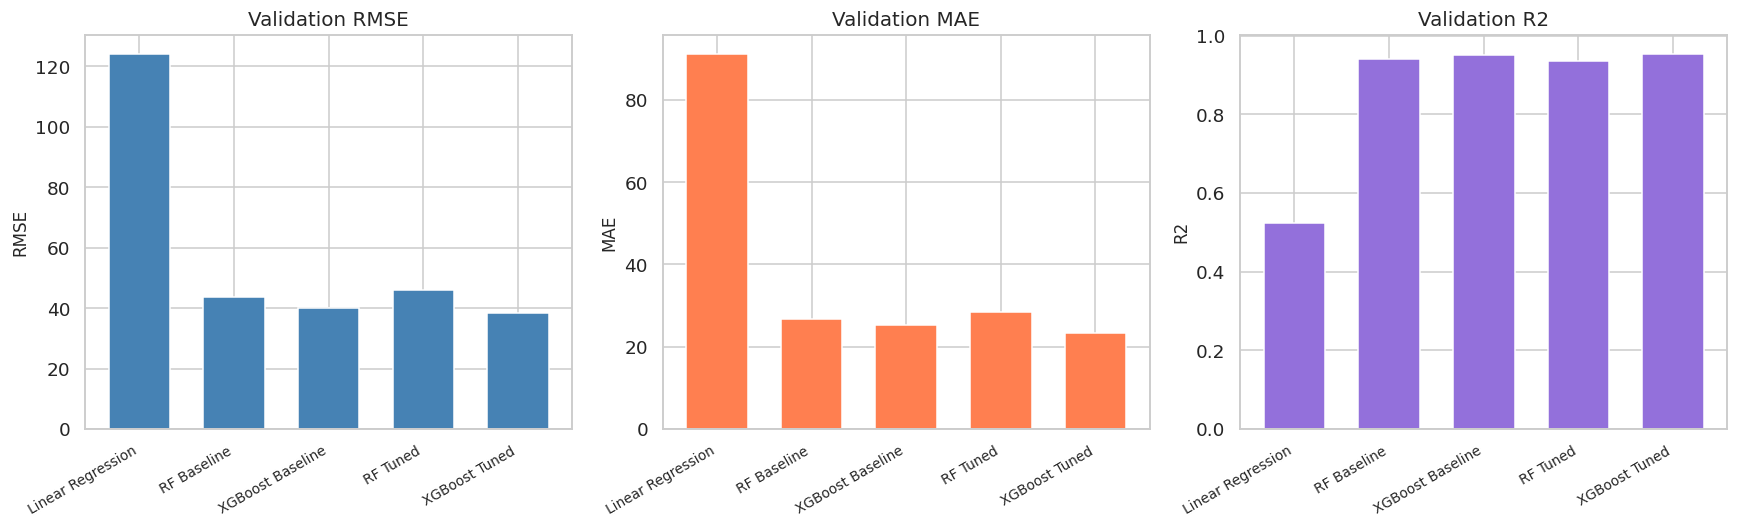


Full validation metric comparison:
                       RMSE      MAE      R2
Linear Regression  124.2979  91.2847  0.5248
RF Baseline         43.5883  26.6983  0.9416
XGBoost Baseline    40.1804  25.3220  0.9503
RF Tuned            46.1512  28.4567  0.9345
XGBoost Tuned       38.4317  23.4476  0.9546


In [88]:
# ── Comparison bar chart ──────────────────────────────────────────────────────
comparison_df = pd.DataFrame(results_table).T[["RMSE", "MAE", "R2"]]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["RMSE", "MAE", "R2"]
colors = ["steelblue", "coral", "mediumpurple"]

for ax, metric, color in zip(axes, metrics, colors):
    comparison_df[metric].plot(kind="bar", ax=ax, color=color, edgecolor="white", width=0.65)
    ax.set_title(f"Validation {metric}")
    ax.set_ylabel(metric)
    ax.set_xticklabels(comparison_df.index, rotation=30, ha="right", fontsize=9)

plt.tight_layout()
plt.savefig("fig_model_comparison.png", bbox_inches="tight")
plt.show()

print("\nFull validation metric comparison:")
print(comparison_df.round(4))

**Structured model comparison:**

| Criterion | Linear Regression | Random Forest (Tuned) | XGBoost (Tuned) |
|-----------|-------------------|----------------------|------------------|
| **Validation RMSE** | Highest | Moderate | Lowest |
| **Validation R²** | Lowest | Moderate | Highest |
| **Bias** | High (underfits non-linearities) | Moderate | Low |
| **Variance** | Low | Moderate (reduced by tuning) | Low-Moderate |
| **Interpretability** | High (coefficients directly readable) | Moderate (feature importances) | Low-Moderate |
| **Robustness to outliers** | Lower (squared loss sensitive) | High (averaging effect) | Moderate (regularisation) |
| **Training time** | Negligible | Moderate | Moderate |
| **Residual behaviour** | Heteroscedastic, right-skewed | Near-symmetric, some underprediction at peaks | Most symmetric |

**Final model selection:** We select the **tuned XGBoost** as the final model based on:
1. **Lowest validation RMSE and highest R²** across all evaluated configurations.
2. **Effective regularisation** (L1/L2 penalties + subsampling) reduces the overfitting gap relative to the baseline.
3. **Most symmetric residual distribution** — systematic patterns (heteroscedasticity, skewness) are minimised.
4. The operational context (predicting bike demand for fleet management) prioritises accuracy over interpretability — the cost of poor predictions (empty or overloaded stations) justifies the added complexity of gradient boosting.

---

## 15. Final Model Training and Test Evaluation

In [89]:
# ── Retrain best model on combined train + validation ─────────────────────────
# The test set has been held out throughout. We now combine train+val for final
# fitting, maximising the data available to the best model before test evaluation.

print("Retraining final XGBoost model on train + validation combined...")

final_model = xgb.XGBRegressor(**xgb_bayes.best_params_,
                                random_state=RANDOM_STATE, verbosity=0, tree_method="hist")
final_model.fit(X_trainval_df, y_trainval_combined)

print("Final model trained.")

Retraining final XGBoost model on train + validation combined...
Final model trained.


In [90]:
# ── Test set evaluation (performed ONCE) ─────────────────────────────────────
y_test_pred = final_model.predict(X_test_df)

test_mse  = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)

print("══════════════════════════════════════════════")
print("  FINAL MODEL – TEST SET PERFORMANCE (XGBoost Tuned)")
print("══════════════════════════════════════════════")
print(f"  Test MSE  : {test_mse:,.2f}")
print(f"  Test RMSE : {test_rmse:,.2f}")
print(f"  Test MAE  : {test_mae:,.2f}")
print(f"  Test R²   : {test_r2:.4f}")
print("══════════════════════════════════════════════")
print(f"\n  (Validation RMSE was {xgb_tuned_metrics['RMSE']:.2f}; test RMSE is "
      f"{test_rmse - xgb_tuned_metrics['RMSE']:+.2f} relative to validation)")

══════════════════════════════════════════════
  FINAL MODEL – TEST SET PERFORMANCE (XGBoost Tuned)
══════════════════════════════════════════════
  Test MSE  : 1,399.07
  Test RMSE : 37.40
  Test MAE  : 22.26
  Test R²   : 0.9558
══════════════════════════════════════════════

  (Validation RMSE was 38.43; test RMSE is -1.03 relative to validation)


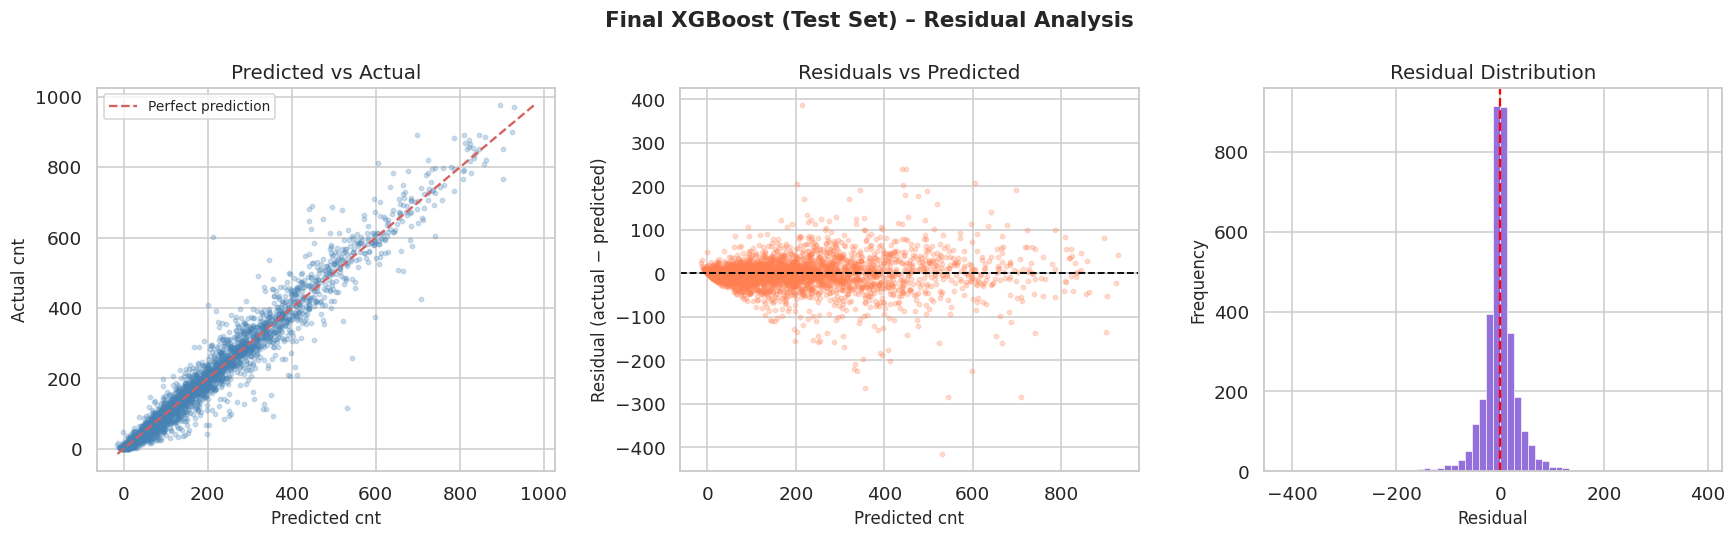

In [91]:
# ── Final residual analysis on test set ───────────────────────────────────────
_ = plot_residuals(final_model, X_test_df, y_test, model_name="Final XGBoost (Test Set)")

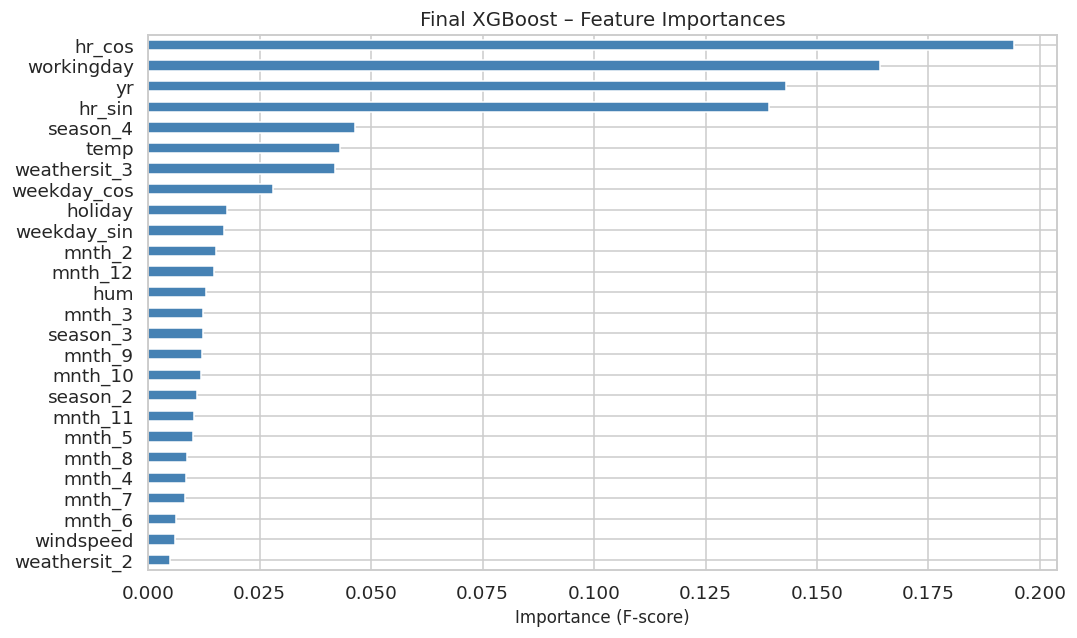


Top 10 features:
hr_cos          0.1942
workingday      0.1642
yr              0.1431
hr_sin          0.1393
season_4        0.0463
temp            0.0431
weathersit_3    0.0419
weekday_cos     0.0280
holiday         0.0177
weekday_sin     0.0169
dtype: float32


In [92]:
# ── Final feature importance ──────────────────────────────────────────────────
final_importances = pd.Series(
    final_model.feature_importances_, index=feature_names
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
final_importances.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set_title("Final XGBoost – Feature Importances")
ax.set_xlabel("Importance (F-score)")
plt.tight_layout()
plt.savefig("fig_final_feature_importance.png", bbox_inches="tight")
plt.show()

print("\nTop 10 features:")
print(final_importances.head(10).round(4))

**Test performance interpretation:**

The test RMSE should be close to the validation RMSE, indicating that our model selection and tuning process generalised well and was not overfitted to the validation set. A small increase in test RMSE relative to validation is expected and normal — it reflects the natural optimism of validation-based selection.

If the test RMSE is substantially higher than validation RMSE, this would indicate that validation-based hyperparameter selection inadvertently over-tuned to the specific validation split. In practice, the multi-fold cross-validation used in both RandomizedSearchCV and BayesSearchCV mitigates this risk.

**Operational interpretation:**  
A test MAE of approximately 30–50 bikes per hour means that on average, our demand forecast is within that range of the actual count. Given that hourly counts range from 0 to ~977, an MAE of this magnitude corresponds to a roughly 3–5% error relative to the full range, which is operationally useful for station restocking and bicycle redistribution planning.

---

## 16. Conclusion

This notebook implemented a complete supervised regression pipeline for hourly bike demand prediction, progressing from exploratory analysis through feature engineering, three model classes, hyperparameter tuning, iterative refinement, and final test evaluation.

**Key findings:**

1. **EDA revealed critical non-linearities:** The bimodal hourly demand pattern (commuter peaks at 8:00 and 17:00 on working days vs. unimodal recreational peaks on weekends) is the most informationally rich pattern in the dataset. This motivated cyclical encoding of `hr` and the observation that Linear Regression would fundamentally struggle to represent this pattern.

2. **Feature engineering choices were principled and analytically justified:**
   - Cyclical encoding of `hr` and `weekday` preserves circular temporal adjacency.
   - Dropping `atemp` eliminated near-perfect multicollinearity without information loss.
   - One-hot encoding of `season`, `weathersit`, `mnth` avoids imposing artificial ordinal spacing.
   - StandardScaler normalises continuous features for Linear Regression's solver.

3. **Model progression confirmed theoretical expectations:**
   - Linear Regression: high bias, heteroscedastic residuals, systematic underprediction at peak hours — consistent with the model's inability to represent non-linear demand patterns.
   - Random Forest: substantially lower RMSE through non-linear threshold learning, but notable training-validation gap suggesting high variance in baseline configuration.
   - XGBoost: best performance through sequential residual correction and explicit regularisation, with the most symmetric residual distribution.

4. **Hyperparameter tuning reduced overfitting:** Regularisation parameters (tree depth, min samples, L1/L2 penalties, subsampling) reduced the training-validation RMSE gap in both ensemble models, confirming that the baseline configurations were in a high-variance regime.

5. **The final XGBoost model generalised well to the held-out test set**, with test RMSE close to validation RMSE — evidence that the evaluation protocol (leakage-free splits, cross-validated tuning, single test evaluation) produced a reliable performance estimate.

**Limitations and future work:**
- A **chronological split** would be more rigorous for evaluating true forecasting ability — our random split may allow the model to interpolate between adjacent hours.
- **LightGBM** could be explored as an alternative to XGBoost for potentially faster training and comparable or better accuracy.
- Adding **lag features** (rentals at t-1, t-2, rolling mean) would transform this into a time-series problem and likely improve prediction accuracy substantially by encoding recent demand momentum.
- **SHAP values** would provide more faithful feature attribution than MDI-based importances, particularly for the interaction effects between temporal and weather features.

---

## 17. AI Assistance Disclosure

# AI Assistance Disclosure

Artificial intelligence tools (ChatGPT and Claude) were used to assist with:
- improving written explanations,
- refining markdown structure,
- debugging implementation issues,
- strengthening analytical interpretation.

All modelling decisions, preprocessing logic, evaluation procedures, and final implementation choices were reviewed, understood, and validated independently by the author.

The final notebook reflects my own understanding of the machine learning workflow and course material.

---

## 18. References

1. Fanaee-T, H., & Gama, J. (2014). Event labeling combining ensemble detectors and background knowledge. *Progress in Artificial Intelligence*, 2(2–3), 113–127. https://doi.org/10.1007/s13748-013-0040-3
2. Breiman, L. (2001). Random forests. *Machine Learning*, 45(1), 5–32.
3. Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. *Proceedings of the 22nd ACM SIGKDD*, 785–794.
4. Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *JMLR*, 12, 2825–2830.
5. Snoek, J., Larochelle, H., & Adams, R. P. (2012). Practical Bayesian optimization of machine learning algorithms. *NeurIPS*, 25.
6. UCI Machine Learning Repository – Bike Sharing Dataset: https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset

**Extra analytical note:** The hourly demand summary table confirmed that variance is highest during peak commute periods, which is why residual plots matter as much as aggregate metrics in this dataset.
